In [ ]:
#Patrones y factores asociados a la consumación de extorsiones registradas por Seguridad 
#Ciudadana en Nezahualcóyotl mediante minería de datos

In [2]:
#Bloque 0. Instalación de librerías
#Ejecuta esto una sola vez
!pip install pandas numpy openpyxl scikit-learn matplotlib mlxtend kmodes

In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [44]:
#Bloque 1. Cargar librerías y archivo
#Fase KDD: Selección de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from kmodes.kmodes import KModes


ruta = "extorsiones.xlsx"
df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
print("\nColumnas originales:")
print(df.columns.tolist())

df.head()

Dimensiones: (1189, 13)

Columnas originales:
['FECHA', 'HORA', 'CUADRANTE', 'DELITO ', 'Delito2a parte', 'OBJETOS ROBADOS', 'UNIDAD QUE PRESTA APOYO', 'DETENCION (PUESTA/REMISION)', 'JERARQUIA', 'SEXO VICTIMA', ' EDAD', 'RANGO DE EDAD', 'GIRO DEL COMERCIO']


,FECHA,HORA,CUADRANTE,DELITO,Delito2a parte,OBJETOS ROBADOS,UNIDAD QUE PRESTA APOYO,DETENCION (PUESTA/REMISION),JERARQUIA,SEXO VICTIMA,EDAD,RANGO DE EDAD,GIRO DEL COMERCIO
0,2025-04-01,18:26:00,C016,LLAMADA DE EXTORSIÓN,Consumada,"$3,000.00 PESOS",V016,DENUNCIA,ALTO IMPACTO,F,74,56 Y MAS,NO APLICA
1,2025-04-01,10:53:00,C062,LLAMADA DE EXTORSIÓN,Evitada,NO APLICA,V062,DENUNCIA,BAJO IMPACTO,F,41,36-45 AÑOS,LOCAL DE COMIDA
2,2025-04-01,12:00:00,C066,LLAMADA DE EXTORSIÓN,Evitada,NO APLICA,V061,DENUNCIA,BAJO IMPACTO,F,36,36-45 AÑOS,LOCAL DE COMIDA
3,2025-04-01,10:02:00,C076,LLAMADA DE EXTORSIÓN,Evitada,NO APLICA,V076,DENUNCIA,BAJO IMPACTO,M,45,36-45 AÑOS,LOCAL DE COMIDA
4,2025-04-02,13:35:00,C014,MENSAJES DE EXTORSIÓN,Evitada,NO APLICA,CASETA 1A,DENUNCIA,BAJO IMPACTO,F,27,26-35 AÑOS,NO APLICA


In [5]:
# BLOQUE 2 Normalizar nombres de columnas
#Aquí está la corrección clave
#Este bloque sustituye el renombrado manual.
#Así evitamos errores por espacios, acentos o paréntesis.
#Fase KDD: Selección + preparación inicial

def normalizar_nombre_columna(col):
    col = str(col).strip().upper()
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    col = re.sub(r'[^A-Z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

df.columns = [normalizar_nombre_columna(c) for c in df.columns]

print("Columnas normalizadas:")
print(df.columns.tolist())

Columnas normalizadas:
['FECHA', 'HORA', 'CUADRANTE', 'DELITO', 'DELITO2A_PARTE', 'OBJETOS_ROBADOS', 'UNIDAD_QUE_PRESTA_APOYO', 'DETENCION_PUESTA_REMISION', 'JERARQUIA', 'SEXO_VICTIMA', 'EDAD', 'RANGO_DE_EDAD', 'GIRO_DEL_COMERCIO']


In [6]:
#Bloque 3. Auditoría rápida de calidad
#Fase KDD: Preprocesamiento
#Esto te dice cuántos valores únicos tiene cada variable, cuántos nulos hay y ejemplos de categorías.

print("Nulos por columna:\n")
print(df.isna().sum())

print("\nValores únicos por columna:\n")
for col in df.columns:
    print(f"\n--- {col} ---")
    print("n_unique:", df[col].nunique(dropna=False))
    print(df[col].astype(str).value_counts(dropna=False).head(10))

Nulos por columna:

FECHA                        0
HORA                         0
CUADRANTE                    0
DELITO                       0
DELITO2A_PARTE               0
OBJETOS_ROBADOS              0
UNIDAD_QUE_PRESTA_APOYO      0
DETENCION_PUESTA_REMISION    0
JERARQUIA                    0
SEXO_VICTIMA                 0
EDAD                         5
RANGO_DE_EDAD                0
GIRO_DEL_COMERCIO            0
dtype: int64

Valores únicos por columna:


--- FECHA ---
n_unique: 306
FECHA
2025-08-25    13
2025-06-12    10
2025-10-08    10
2025-07-11    10
2025-09-26    10
2025-11-04     9
2025-07-09     9
2025-07-24     9
2025-08-26     9
2025-07-21     9
Name: count, dtype: int64

--- HORA ---
n_unique: 442
HORA
17:00:00    23
14:00:00    23
14:30:00    20
12:00:00    19
15:00:00    18
16:00:00    17
12:30:00    17
16:30:00    16
11:30:00    16
13:00:00    15
Name: count, dtype: int64

--- CUADRANTE ---
n_unique: 107
CUADRANTE
C131       29
C087       22
C088       22
C064     

In [7]:
#Bloque 4. Funciones de limpieza
#Fase KDD: Preprocesamiento
#Aquí limpiamos texto, acentos, espacios y estandarizamos categorías.

def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"\s+", " ", x)
    return x

def quitar_acentos(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

cols_texto_esperadas = [
    "CUADRANTE",
    "DELITO",
    "DELITO2A_PARTE",
    "OBJETOS_ROBADOS",
    "UNIDAD_QUE_PRESTA_APOYO",
    "DETENCION_PUESTA_REMISION",
    "JERARQUIA",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "GIRO_DEL_COMERCIO"
]

# Solo usa columnas que realmente existen
cols_texto = [c for c in cols_texto_esperadas if c in df.columns]

for col in cols_texto:
    df[col] = df[col].apply(limpiar_texto)

# Estandarizaciones puntuales
if "JERARQUIA" in df.columns:
    df["JERARQUIA"] = df["JERARQUIA"].replace({
        "ALTO IMPACTO ": "ALTO IMPACTO",
        "ALTO  IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO.": "ALTO IMPACTO",
        "ALTO IMPACTO,": "ALTO IMPACTO",
        "ALTO IMPACTO/": "ALTO IMPACTO",
        "ALTO IMPACTO-": "ALTO IMPACTO",
        "ALTO IMPACTO_": "ALTO IMPACTO",
        "ALTO IMPACTO  ": "ALTO IMPACTO",
        "ALTO IMPACTO\t": "ALTO IMPACTO",
        "ALTO IMPACTO\r": "ALTO IMPACTO",
        "ALTO IMPACTO\n": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO".upper(): "ALTO IMPACTO",
        "ALTO IMPACTO".strip(): "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "ALTO IMPACTO": "ALTO IMPACTO",
        "AlTO IMPACTO".upper(): "ALTO IMPACTO"
    })

if "SEXO_VICTIMA" in df.columns:
    df["SEXO_VICTIMA"] = df["SEXO_VICTIMA"].replace({
        "F ": "F",
        "M ": "M",
        "NO ESPECIFICA": "NP"
    })

if "RANGO_DE_EDAD" in df.columns:
    df["RANGO_DE_EDAD"] = df["RANGO_DE_EDAD"].replace({
        "56 Y MAS ": "56 Y MAS"
    })

print("\nValores de SEXO_VICTIMA:")
print(df["SEXO_VICTIMA"].value_counts(dropna=False))

print("\nValores de JERARQUIA:")
print(df["JERARQUIA"].value_counts(dropna=False))

print("\nValores de RANGO_DE_EDAD:")
print(df["RANGO_DE_EDAD"].value_counts(dropna=False))


Valores de SEXO_VICTIMA:
SEXO_VICTIMA
M        632
F        544
F Y M      9
NP         4
Name: count, dtype: int64

Valores de JERARQUIA:
JERARQUIA
BAJO IMPACTO    1056
ALTO IMPACTO     133
Name: count, dtype: int64

Valores de RANGO_DE_EDAD:
RANGO_DE_EDAD
56 Y MAS       253
26-35 AÑOS     248
46-55 AÑOS     219
36-45 AÑOS     216
18-25 AÑOS     116
DESCONOCIDO    110
02-17 AÑOS      27
Name: count, dtype: int64


In [8]:
#BLOQUE 5. Limpieza de fecha, hora y edad
#Fase KDD: Preprocesamiento

In [9]:
# FECHA
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

# HORA
def convertir_hora(x):
    if pd.isna(x):
        return np.nan
    try:
        return pd.to_datetime(str(x), format="%H:%M:%S", errors="coerce").time()
    except:
        try:
            return pd.to_datetime(str(x), format="%H:%M", errors="coerce").time()
        except:
            return np.nan

df["HORA"] = df["HORA"].apply(convertir_hora)

# EDAD
df["EDAD"] = df["EDAD"].astype(str).str.strip().replace({
    "NP": np.nan,
    "N/P": np.nan,
    "NO ESPECIFICA": np.nan,
    "NAN": np.nan
})

df["EDAD_LIMPIA"] = pd.to_numeric(df["EDAD"], errors="coerce")

print(df[["FECHA", "HORA", "EDAD", "EDAD_LIMPIA"]].head())
print("\nNulos en EDAD_LIMPIA:", df["EDAD_LIMPIA"].isna().sum())

       FECHA      HORA EDAD  EDAD_LIMPIA
0 2025-04-01  18:26:00   74         74.0
1 2025-04-01  10:53:00   41         41.0
2 2025-04-01  12:00:00   36         36.0
3 2025-04-01  10:02:00   45         45.0
4 2025-04-02  13:35:00   27         27.0

Nulos en EDAD_LIMPIA: 115


In [10]:
#BLOQUE 6. Variables derivadas
#Fase KDD: Transformación

In [11]:
# Variable objetivo binaria
df["TARGET_CONSUMADA"] = df["DELITO2A_PARTE"].map({
    "EVITADA": 0,
    "CONSUMADA": 1
})

# Mes
df["MES"] = df["FECHA"].dt.month

# Día de semana
dias = {
    0: "LUNES",
    1: "MARTES",
    2: "MIERCOLES",
    3: "JUEVES",
    4: "VIERNES",
    5: "SABADO",
    6: "DOMINGO"
}
df["DIA_SEMANA"] = df["FECHA"].dt.dayofweek.map(dias)

# Fin de semana
df["FIN_SEMANA"] = df["DIA_SEMANA"].isin(["SABADO", "DOMINGO"]).astype(int)

# Convertir hora a número
def hora_a_numero(hora):
    if pd.isna(hora):
        return np.nan
    return hora.hour + hora.minute / 60

df["HORA_NUM"] = df["HORA"].apply(hora_a_numero)

# Franja horaria
def clasificar_franja(h):
    if pd.isna(h):
        return "DESCONOCIDA"
    if 0 <= h < 6:
        return "MADRUGADA"
    elif 6 <= h < 12:
        return "MANANA"
    elif 12 <= h < 18:
        return "TARDE"
    else:
        return "NOCHE"

df["FRANJA_HORARIA"] = df["HORA_NUM"].apply(clasificar_franja)

# Tipo general de extorsión
def tipo_extorsion_general(delito):
    if pd.isna(delito):
        return "OTRO"

    d = quitar_acentos(str(delito).upper())

    if "LLAMADA" in d:
        return "LLAMADA"
    elif "MENSAJE" in d:
        return "MENSAJE"
    elif "PRESENCIAL" in d:
        return "PRESENCIAL"
    elif "EXTORSION" in d:
        return "EXTORSION"
    else:
        return "OTRO"

df["TIPO_EXTORSION"] = df["DELITO"].apply(tipo_extorsion_general)

# Agrupar giros poco frecuentes
top_giros = df["GIRO_DEL_COMERCIO"].value_counts().head(15).index
df["GIRO_COMERCIO_RED"] = np.where(
    df["GIRO_DEL_COMERCIO"].isin(top_giros),
    df["GIRO_DEL_COMERCIO"],
    "OTROS"
)

print(df[[
    "DELITO2A_PARTE",
    "TARGET_CONSUMADA",
    "MES",
    "DIA_SEMANA",
    "FIN_SEMANA",
    "HORA_NUM",
    "FRANJA_HORARIA",
    "TIPO_EXTORSION",
    "GIRO_COMERCIO_RED"
]].head())

  DELITO2A_PARTE  TARGET_CONSUMADA  MES DIA_SEMANA  FIN_SEMANA   HORA_NUM  \
0      CONSUMADA                 1    4     MARTES           0  18.433333   
1        EVITADA                 0    4     MARTES           0  10.883333   
2        EVITADA                 0    4     MARTES           0  12.000000   
3        EVITADA                 0    4     MARTES           0  10.033333   
4        EVITADA                 0    4  MIERCOLES           0  13.583333   

  FRANJA_HORARIA TIPO_EXTORSION GIRO_COMERCIO_RED  
0          NOCHE        LLAMADA         NO APLICA  
1         MANANA        LLAMADA   LOCAL DE COMIDA  
2          TARDE        LLAMADA   LOCAL DE COMIDA  
3         MANANA        LLAMADA   LOCAL DE COMIDA  
4          TARDE        MENSAJE         NO APLICA  


In [12]:
#BLOQUE 7. Guardar base limpia
#Fase KDD: Cierre del preprocesamiento

In [13]:
df.to_excel("extorsiones_limpia.xlsx", index=False)
print("Archivo guardado: extorsiones_limpia.xlsx")

Archivo guardado: extorsiones_limpia.xlsx


In [14]:
#BLOQUE 8. Exploración básica
#Fase KDD: Exploración

In [15]:
print("Resultado del caso:")
print(df["DELITO2A_PARTE"].value_counts())

print("\nTipo general de extorsión:")
print(df["TIPO_EXTORSION"].value_counts())

print("\nFranja horaria:")
print(df["FRANJA_HORARIA"].value_counts())

print("\nTop 10 cuadrantes:")
print(df["CUADRANTE"].value_counts().head(10))

print("\nCruce Resultado vs Franja horaria:")
print(pd.crosstab(df["FRANJA_HORARIA"], df["DELITO2A_PARTE"], margins=True))

print("\nCruce Resultado vs Tipo de extorsión:")
print(pd.crosstab(df["TIPO_EXTORSION"], df["DELITO2A_PARTE"], margins=True))

print("\nCruce Resultado vs Cuadrante (top 15):")
top15 = df["CUADRANTE"].value_counts().head(15).index
print(pd.crosstab(
    df[df["CUADRANTE"].isin(top15)]["CUADRANTE"],
    df[df["CUADRANTE"].isin(top15)]["DELITO2A_PARTE"],
    margins=True
))

Resultado del caso:
DELITO2A_PARTE
EVITADA      1041
CONSUMADA     148
Name: count, dtype: int64

Tipo general de extorsión:
TIPO_EXTORSION
LLAMADA       966
MENSAJE       113
PRESENCIAL     85
EXTORSION      20
OTRO            5
Name: count, dtype: int64

Franja horaria:
FRANJA_HORARIA
TARDE        721
MANANA       233
NOCHE        207
MADRUGADA     28
Name: count, dtype: int64

Top 10 cuadrantes:
CUADRANTE
C131       29
C087       22
C088       22
C064       21
C095       20
C146       19
C021       19
C041       19
NO ESP.    19
C153       19
Name: count, dtype: int64

Cruce Resultado vs Franja horaria:
DELITO2A_PARTE  CONSUMADA  EVITADA   All
FRANJA_HORARIA                          
MADRUGADA               7       21    28
MANANA                 23      210   233
NOCHE                  39      168   207
TARDE                  79      642   721
All                   148     1041  1189

Cruce Resultado vs Tipo de extorsión:
DELITO2A_PARTE  CONSUMADA  EVITADA   All
TIPO_EXTORSION     

In [ ]:
#BLOQUE 9. Gráficas básicas EDA
#Fase KDD: Exploración

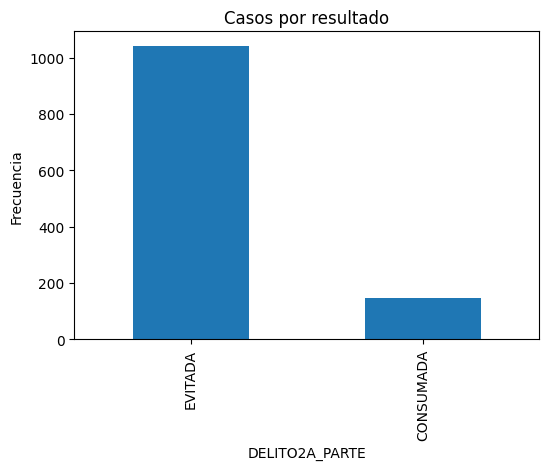

In [16]:
df["DELITO2A_PARTE"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Casos por resultado")
plt.ylabel("Frecuencia")
plt.show()

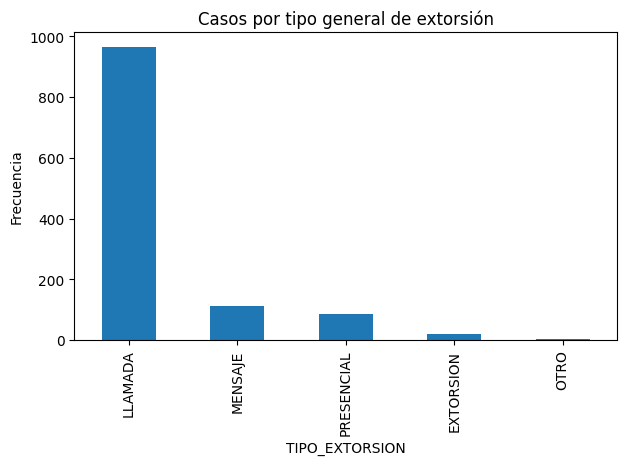

In [17]:
df["TIPO_EXTORSION"].value_counts().plot(kind="bar", figsize=(7,4))
plt.title("Casos por tipo general de extorsión")
plt.ylabel("Frecuencia")
plt.show()

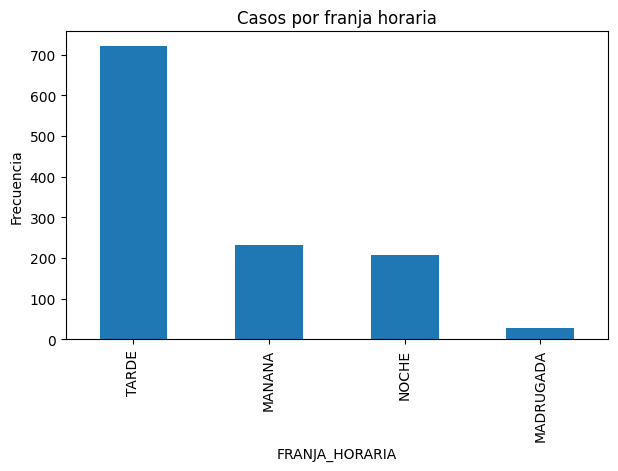

In [18]:
df["FRANJA_HORARIA"].value_counts().plot(kind="bar", figsize=(7,4))
plt.title("Casos por franja horaria")
plt.ylabel("Frecuencia")
plt.show()

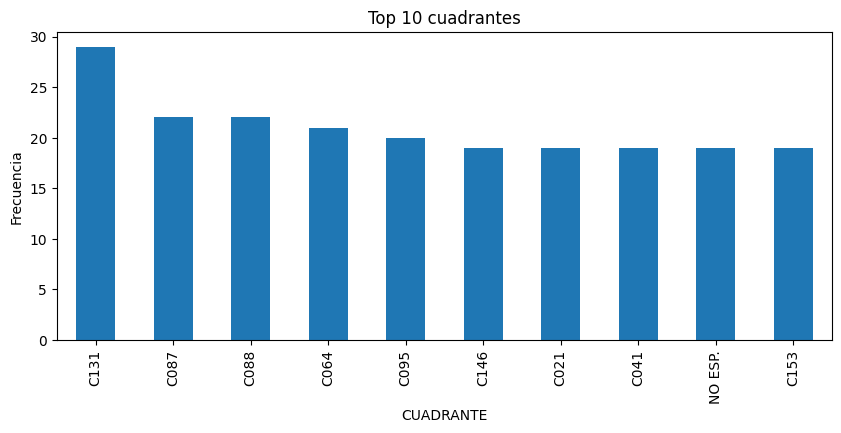

In [19]:
df["CUADRANTE"].value_counts().head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top 10 cuadrantes")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
#EDA ampliado

In [ ]:
#BLOQUE 9.1. Frecuencia por mes

FECHA
2025-03      1
2025-04     86
2025-05    117
2025-06    110
2025-07    149
2025-08    150
2025-09    141
2025-10    104
2025-11     97
2025-12    112
2026-01     89
2026-02     33
Name: count, dtype: int64


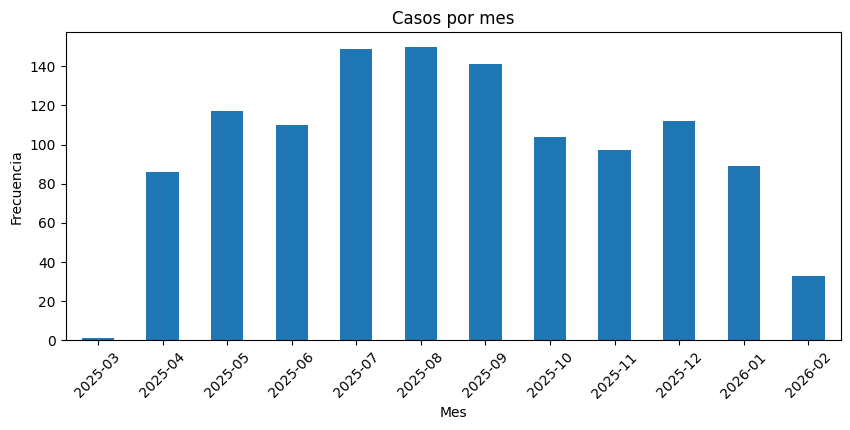

In [20]:
casos_mes = df["FECHA"].dt.to_period("M").astype(str).value_counts().sort_index()

print(casos_mes)

casos_mes.plot(kind="bar", figsize=(10,4))
plt.title("Casos por mes")
plt.ylabel("Frecuencia")
plt.xlabel("Mes")
plt.xticks(rotation=45)
plt.show()

DIA_SEMANA
LUNES        201
MARTES       183
MIERCOLES    170
JUEVES       189
VIERNES      180
SABADO       161
DOMINGO      105
Name: count, dtype: int64


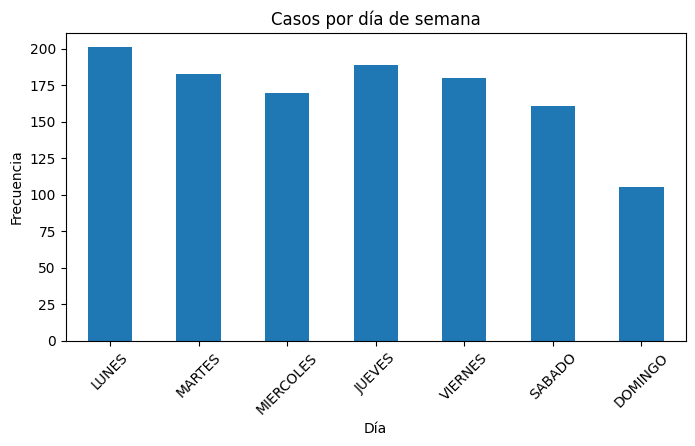

In [21]:
#BLOQUE 9.2. Frecuencia por día de semana
orden_dias = ["LUNES", "MARTES", "MIERCOLES", "JUEVES", "VIERNES", "SABADO", "DOMINGO"]
casos_dia = df["DIA_SEMANA"].value_counts().reindex(orden_dias)

print(casos_dia)

casos_dia.plot(kind="bar", figsize=(8,4))
plt.title("Casos por día de semana")
plt.ylabel("Frecuencia")
plt.xlabel("Día")
plt.xticks(rotation=45)
plt.show()

HORA_ENTERA
0      10
1       7
2       2
3       3
4       3
5       3
6       3
7       5
8      16
9      28
10     81
11    100
12    129
13    126
14    136
15    101
16    121
17    108
18     70
19     31
20     35
21     30
22     24
23     17
Name: count, dtype: int64


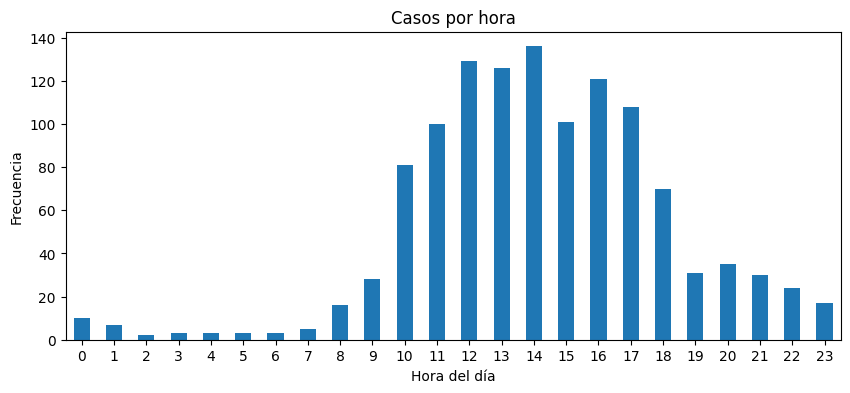

In [22]:
#BLOQUE 9.3. Frecuencia por hora
df["HORA_ENTERA"] = df["HORA_NUM"].fillna(-1).astype(int)

casos_hora = df[df["HORA_ENTERA"] >= 0]["HORA_ENTERA"].value_counts().sort_index()

print(casos_hora)

casos_hora.plot(kind="bar", figsize=(10,4))
plt.title("Casos por hora")
plt.ylabel("Frecuencia")
plt.xlabel("Hora del día")
plt.xticks(rotation=0)
plt.show()

DELITO2A_PARTE  CONSUMADA  EVITADA
TIPO_EXTORSION                    
EXTORSION              15        5
LLAMADA                95      871
MENSAJE                 3      110
OTRO                    1        4
PRESENCIAL             34       51


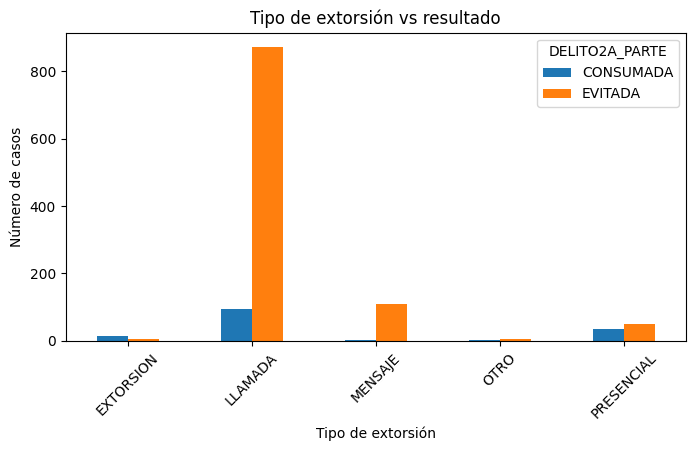

In [23]:
#BLOQUE 9.4. Tabla de contingencia simple
tabla_resultado_tipo = pd.crosstab(df["TIPO_EXTORSION"], df["DELITO2A_PARTE"])
print(tabla_resultado_tipo)

tabla_resultado_tipo.plot(kind="bar", figsize=(8,4))
plt.title("Tipo de extorsión vs resultado")
plt.ylabel("Número de casos")
plt.xlabel("Tipo de extorsión")
plt.xticks(rotation=45)
plt.show()

FRANJA_HORARIA  MADRUGADA  MANANA  NOCHE  TARDE
DIA_SEMANA                                     
LUNES                   3      41     34    123
MARTES                  5      38     31    109
MIERCOLES               4      37     32     97
JUEVES                  4      44     28    113
VIERNES                 6      32     32    110
SABADO                  3      25     30    103
DOMINGO                 3      16     20     66


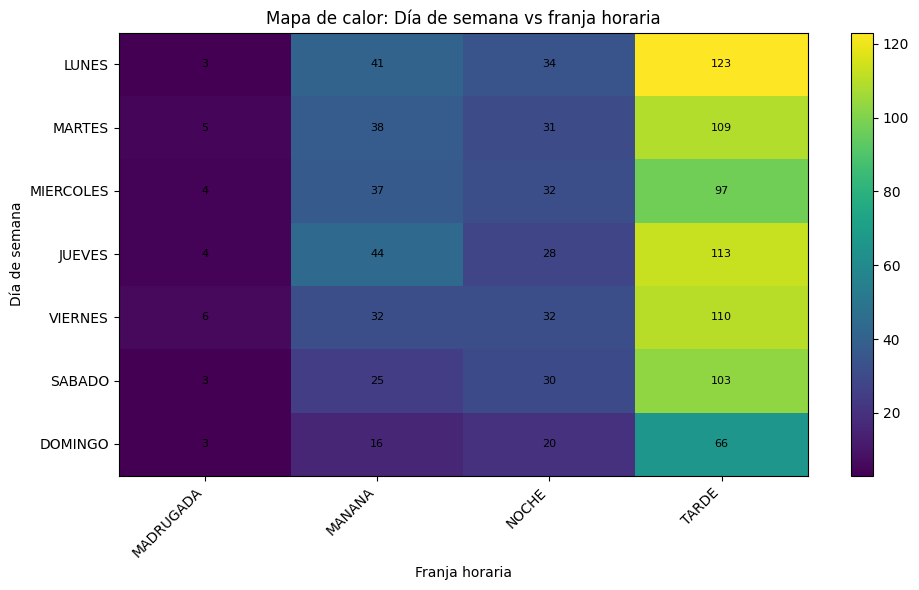

In [26]:
#BLOQUE 9.5. Función para mapas de calor
def plot_heatmap(tabla, titulo, xlabel="", ylabel="", fmt=".0f"):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(tabla.values, aspect="auto")

    ax.set_xticks(np.arange(len(tabla.columns)))
    ax.set_yticks(np.arange(len(tabla.index)))

    ax.set_xticklabels(tabla.columns, rotation=45, ha="right")
    ax.set_yticklabels(tabla.index)

    for i in range(tabla.shape[0]):
        for j in range(tabla.shape[1]):
            valor = tabla.iloc[i, j]
            texto = f"{valor:{fmt}}" if isinstance(valor, (int, float, np.integer, np.floating)) else str(valor)
            ax.text(j, i, texto, ha="center", va="center", fontsize=8)

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

#BLOQUE 9.6. Mapa de calor: día de semana vs franja horaria
tabla_dia_franja = pd.crosstab(
    df["DIA_SEMANA"],
    df["FRANJA_HORARIA"]
).reindex(orden_dias)

print(tabla_dia_franja)
plot_heatmap(
    tabla_dia_franja.fillna(0),
    titulo="Mapa de calor: Día de semana vs franja horaria",
    xlabel="Franja horaria",
    ylabel="Día de semana"
)

DELITO2A_PARTE  CONSUMADA  EVITADA
TIPO_EXTORSION                    
EXTORSION              15        5
LLAMADA                95      871
MENSAJE                 3      110
OTRO                    1        4
PRESENCIAL             34       51


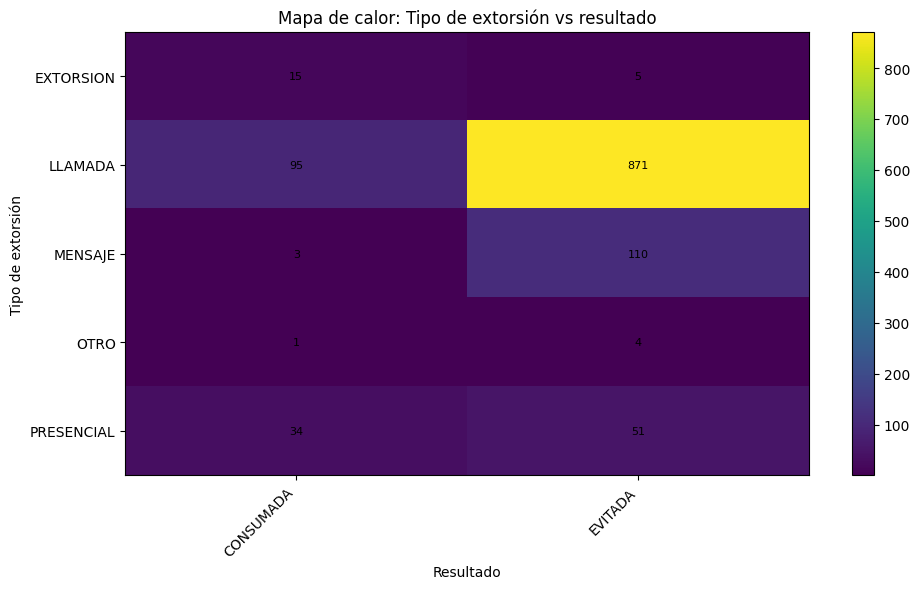

In [27]:
#BLOQUE 9.7. Mapa de calor: tipo de extorsión vs resultado
tabla_tipo_resultado = pd.crosstab(
    df["TIPO_EXTORSION"],
    df["DELITO2A_PARTE"]
)

print(tabla_tipo_resultado)
plot_heatmap(
    tabla_tipo_resultado,
    titulo="Mapa de calor: Tipo de extorsión vs resultado",
    xlabel="Resultado",
    ylabel="Tipo de extorsión"
)



DELITO2A_PARTE  CONSUMADA  EVITADA
CUADRANTE                         
C021                    1       18
C041                    1       18
C044                    7       12
C064                    1       20
C083                    1       17
C087                    1       21
C088                    1       21
C095                    0       20
C117                    3       15
C131                    4       25
C146                    1       18
C151                    4       14
C152                    2       16
C153                    3       16
NO ESP.                 8       11


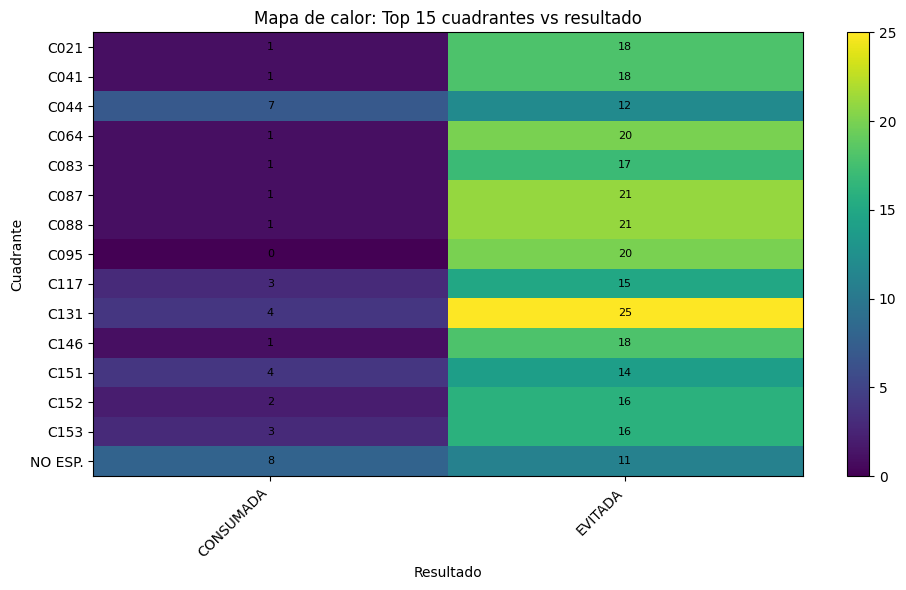

In [28]:
#BLOQUE 9.8. Mapa de calor: top cuadrantes vs resultado
top_cuadrantes = df["CUADRANTE"].value_counts().head(15).index

tabla_cuadrantes = pd.crosstab(
    df[df["CUADRANTE"].isin(top_cuadrantes)]["CUADRANTE"],
    df[df["CUADRANTE"].isin(top_cuadrantes)]["DELITO2A_PARTE"]
)

print(tabla_cuadrantes)
plot_heatmap(
    tabla_cuadrantes,
    titulo="Mapa de calor: Top 15 cuadrantes vs resultado",
    xlabel="Resultado",
    ylabel="Cuadrante"
)

DELITO2A_PARTE         CONSUMADA  EVITADA
GIRO_COMERCIO_RED                        
ABARROTES                   11.1     88.9
BARBERIA Y/O ESTETICA        0.0    100.0
DOMICILIO                    9.2     90.8
LOCAL COMERCIAL              0.0    100.0
LOCAL DE COMIDA              7.1     92.9
MECANICO                    20.0     80.0
NO APLICA                   16.6     83.4
OTROS                        9.3     90.7
PAPELERIA                    0.0    100.0
PURIFICADORA                15.0     85.0
TAQUERIA                     7.1     92.9
VETERINARIA                  0.0    100.0


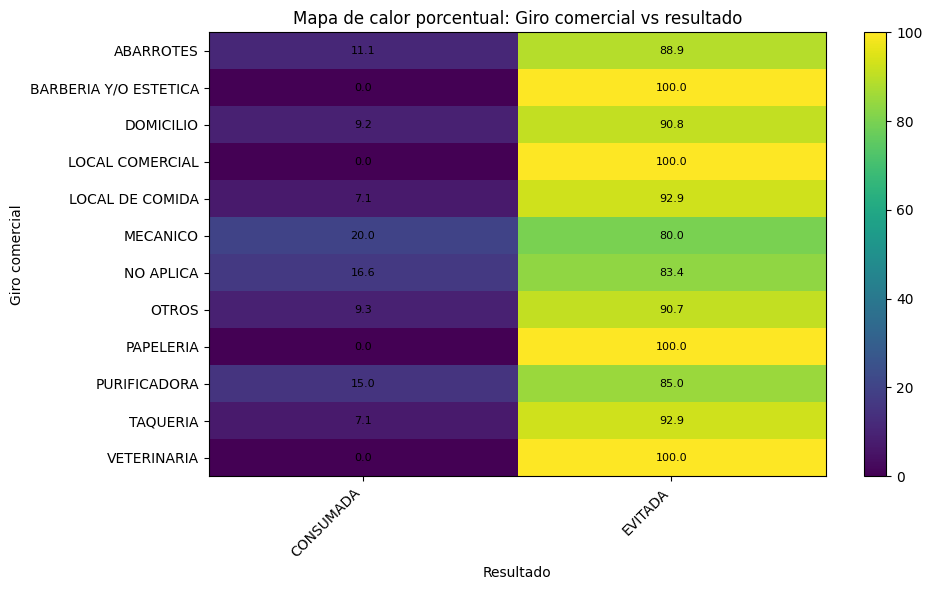

In [29]:

#BLOQUE 9.9. Mapa de calor porcentual: giro comercial vs resultado
top_giros_eda = df["GIRO_COMERCIO_RED"].value_counts().head(12).index

tabla_giro_resultado = pd.crosstab(
    df[df["GIRO_COMERCIO_RED"].isin(top_giros_eda)]["GIRO_COMERCIO_RED"],
    df[df["GIRO_COMERCIO_RED"].isin(top_giros_eda)]["DELITO2A_PARTE"],
    normalize="index"
) * 100

tabla_giro_resultado = tabla_giro_resultado.round(1)

print(tabla_giro_resultado)
plot_heatmap(
    tabla_giro_resultado,
    titulo="Mapa de calor porcentual: Giro comercial vs resultado",
    xlabel="Resultado",
    ylabel="Giro comercial",
    fmt=".1f"
)

DELITO2A_PARTE  CONSUMADA  EVITADA
FRANJA_HORARIA                    
MADRUGADA             7.0     21.0
MANANA               23.0    210.0
TARDE                79.0    642.0
NOCHE                39.0    168.0
DESCONOCIDA           NaN      NaN


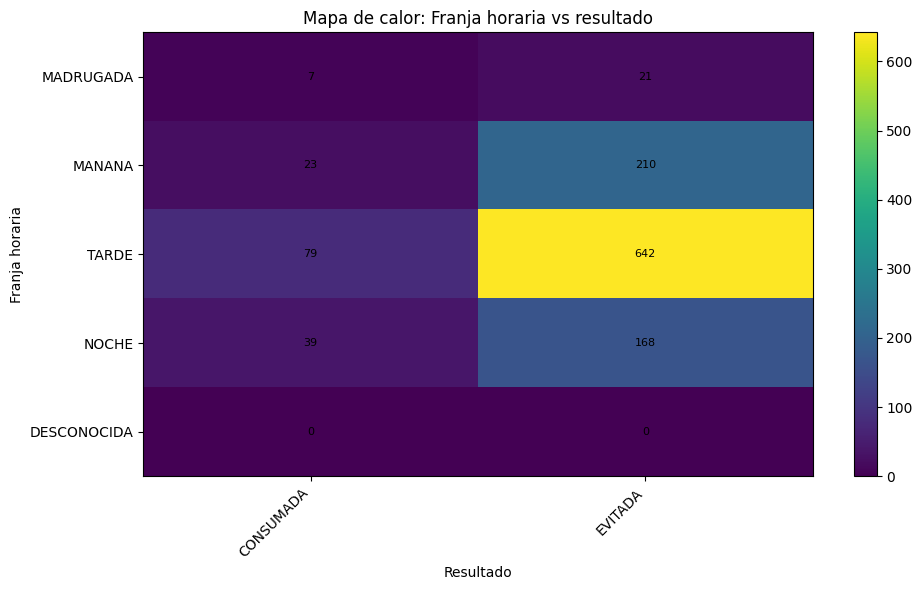

In [30]:
#BLOQUE 9.10. Mapa de calor: franja horaria vs resultado
orden_franjas = ["MADRUGADA", "MANANA", "TARDE", "NOCHE", "DESCONOCIDA"]

tabla_franja_resultado = pd.crosstab(
    df["FRANJA_HORARIA"],
    df["DELITO2A_PARTE"]
).reindex(orden_franjas)

print(tabla_franja_resultado)
plot_heatmap(
    tabla_franja_resultado.fillna(0),
    titulo="Mapa de calor: Franja horaria vs resultado",
    xlabel="Resultado",
    ylabel="Franja horaria"
)

                  EDAD_LIMPIA  TARGET_CONSUMADA   MES  FIN_SEMANA  HORA_NUM
EDAD_LIMPIA              1.00              0.02  0.01        0.01     -0.06
TARGET_CONSUMADA         0.02              1.00 -0.06        0.02      0.03
MES                      0.01             -0.06  1.00        0.02     -0.01
FIN_SEMANA               0.01              0.02  0.02        1.00      0.04
HORA_NUM                -0.06              0.03 -0.01        0.04      1.00


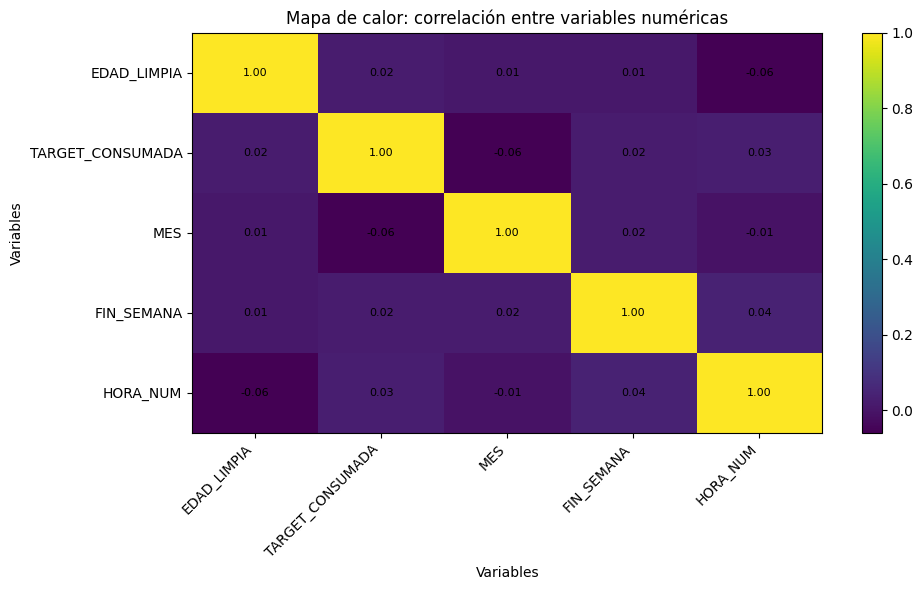

In [31]:
#BLOQUE 9.11. Matriz de correlación de variables numéricas
#Aquí no habrá muchas variables numéricas, pero sirve para revisar relaciones básicas.

corr_cols = ["EDAD_LIMPIA", "TARGET_CONSUMADA", "MES", "FIN_SEMANA", "HORA_NUM"]
corr_df = df[corr_cols].copy()

matriz_corr = corr_df.corr(numeric_only=True).round(2)
print(matriz_corr)

plot_heatmap(
    matriz_corr,
    titulo="Mapa de calor: correlación entre variables numéricas",
    xlabel="Variables",
    ylabel="Variables",
    fmt=".2f"
)

In [32]:
#BLOQUE 9.12. Validación final antes del modelado
df_model = df.copy()

# 1. Eliminar duplicados exactos
duplicados = df_model.duplicated().sum()
print("Duplicados exactos:", duplicados)

df_model = df_model.drop_duplicates().copy()

# 2. Verificar target
print("\nNulos en TARGET_CONSUMADA:")
print(df_model["TARGET_CONSUMADA"].isna().sum())

# 3. Filtrar por target válido
df_model = df_model[df_model["TARGET_CONSUMADA"].isin([0, 1])].copy()

print("\nDistribución del target:")
print(df_model["TARGET_CONSUMADA"].value_counts())
print(df_model["TARGET_CONSUMADA"].value_counts(normalize=True).round(4))

# 4. Revisión de nulos en variables candidatas
features_revision = [
    "CUADRANTE",
    "JERARQUIA",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "GIRO_COMERCIO_RED",
    "DETENCION_PUESTA_REMISION",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "DIA_SEMANA",
    "FIN_SEMANA"
]

print("\nNulos en variables candidatas:")
print(df_model[features_revision].isna().sum().sort_values(ascending=False))

Duplicados exactos: 0

Nulos en TARGET_CONSUMADA:
0

Distribución del target:
TARGET_CONSUMADA
0    1041
1     148
Name: count, dtype: int64
TARGET_CONSUMADA
0    0.8755
1    0.1245
Name: proportion, dtype: float64

Nulos en variables candidatas:
CUADRANTE                    0
JERARQUIA                    0
SEXO_VICTIMA                 0
RANGO_DE_EDAD                0
GIRO_COMERCIO_RED            0
DETENCION_PUESTA_REMISION    0
TIPO_EXTORSION               0
FRANJA_HORARIA               0
DIA_SEMANA                   0
FIN_SEMANA                   0
dtype: int64


In [33]:
#BLOQUE 9.13. Definir dos conjuntos de variables
#uno explicativo y otro operativo
# Modelo explicativo: útil para entender asociaciones del caso
features_explicativas = [
    "CUADRANTE",
    "JERARQUIA",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "GIRO_COMERCIO_RED",
    "DETENCION_PUESTA_REMISION",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "DIA_SEMANA",
    "FIN_SEMANA"
]

# Modelo operativo: más limpio para un uso preventivo
features_operativas = [
    "CUADRANTE",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "GIRO_COMERCIO_RED",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "DIA_SEMANA",
    "FIN_SEMANA"
]

print("Variables explicativas:", features_explicativas)
print("\nVariables operativas:", features_operativas)

Variables explicativas: ['CUADRANTE', 'JERARQUIA', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'DETENCION_PUESTA_REMISION', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA']

Variables operativas: ['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA']


In [34]:
#BLOQUE 10. Separar train y test
#Usaremos primero el modelo operativo

# =========================================
# BLOQUE 10: TRAIN / TEST SPLIT
# =========================================

# Elige aquí qué conjunto de variables quieres usar:
features = features_operativas
# features = features_explicativas

target = "TARGET_CONSUMADA"

X = df_model[features].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Variables seleccionadas:")
print(features)

print("\nDimensiones:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución del target en train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribución del target en test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(4))

Variables seleccionadas:
['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA']

Dimensiones:
X_train: (832, 8)
X_test : (357, 8)
y_train: (832,)
y_test : (357,)

Distribución del target en train:
TARGET_CONSUMADA
0    728
1    104
Name: count, dtype: int64
TARGET_CONSUMADA
0    0.875
1    0.125
Name: proportion, dtype: float64

Distribución del target en test:
TARGET_CONSUMADA
0    313
1     44
Name: count, dtype: int64
TARGET_CONSUMADA
0    0.8768
1    0.1232
Name: proportion, dtype: float64


In [35]:
#BLOQUE 11. Definir variables categóricas y numéricas + pipeline
#Este bloque prepara el preprocesamiento correcto
# =========================================
# BLOQUE 11: PREPROCESAMIENTO PARA MODELOS
# =========================================

# Detectar automáticamente qué variables son categóricas y cuáles numéricas
categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:")
print(categoricas)

print("\nVariables numéricas:")
print(numericas)

preprocesador = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categoricas),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), numericas)
    ],
    remainder="drop"
)

print("\nPreprocesador listo.")

Variables categóricas:
['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA']

Variables numéricas:
['FIN_SEMANA']

Preprocesador listo.


In [36]:
#Validación rápida después del Bloque 11
#Este mini-bloque te sirve para revisar que todo está consistente antes de entrenar el árbol.
print("Número de variables en X_train:", X_train.shape[1])
print("Número de variables categóricas:", len(categoricas))
print("Número de variables numéricas:", len(numericas))

Número de variables en X_train: 8
Número de variables categóricas: 7
Número de variables numéricas: 1


In [45]:
# =========================================
# BLOQUE 11.1: FUNCIÓN GENERAL DE EVALUACIÓN
# =========================================

def evaluar_modelo(modelo, X_test, y_test, nombre_modelo="Modelo"):
    # Predicciones
    y_pred = modelo.predict(X_test)

    # Probabilidades, si el modelo las soporta
    y_prob = None
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]

    # Reporte de clasificación como diccionario
    reporte_dict = classification_report(y_test, y_pred, output_dict=True)
    tabla_metricas = pd.DataFrame(reporte_dict).T.round(4)

    # Métricas globales
    metricas_globales = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    }

    if y_prob is not None:
        metricas_globales["roc_auc"] = roc_auc_score(y_test, y_prob)
        metricas_globales["average_precision"] = average_precision_score(y_test, y_prob)

    tabla_global = pd.DataFrame(
        list(metricas_globales.items()),
        columns=["metrica", "valor"]
    ).round(4)

    # Mostrar tablas
    print(f"\n=== {nombre_modelo.upper()} ===")
    print("\nTabla de métricas por clase:")
    display(tabla_metricas)

    print("\nMétricas globales:")
    display(tabla_global)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    # Curva ROC
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Curva ROC - {nombre_modelo}")
        plt.legend()
        plt.show()

        # Curva Precision-Recall
        precision, recall, _ = precision_recall_curve(y_test, y_prob)

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_prob):.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Curva Precision-Recall - {nombre_modelo}")
        plt.legend()
        plt.show()

    return y_pred, y_prob, tabla_metricas, tabla_global

In [ ]:
#BLOQUE 12. Entrenar Árbol de Decisión
#Primer modelo de clasificación


=== ÁRBOL DE DECISIÓN ===

Tabla de métricas por clase:


,precision,recall,f1-score,support
0,0.9381,0.5815,0.7179,313.0000
1,0.1963,0.7273,0.3092,44.0000
accuracy,0.5994,0.5994,0.5994,0.5994
macro avg,0.5672,0.6544,0.5136,357.0000
weighted avg,0.8467,0.5994,0.6676,357.0000



Métricas globales:


,metrica,valor
0,accuracy,0.5994
1,balanced_accuracy,0.6544
2,roc_auc,0.6868
3,average_precision,0.2492


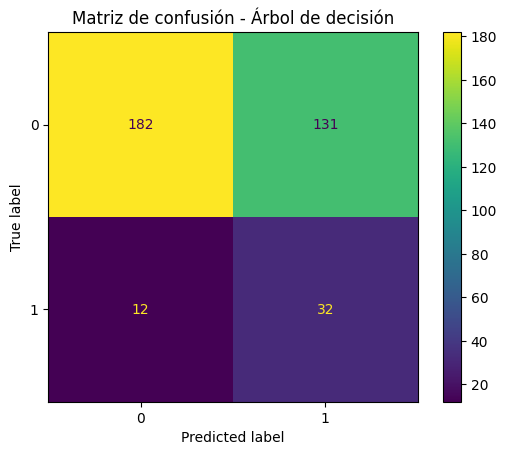

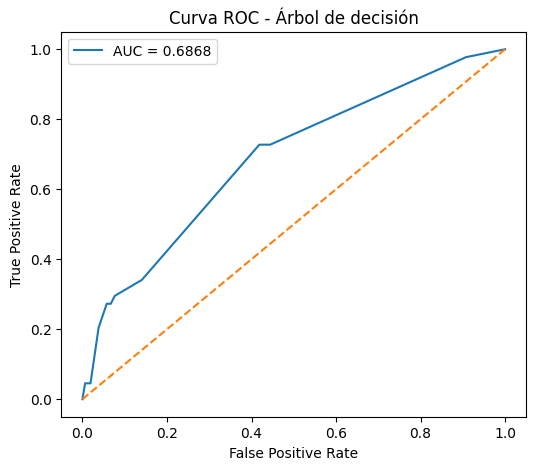

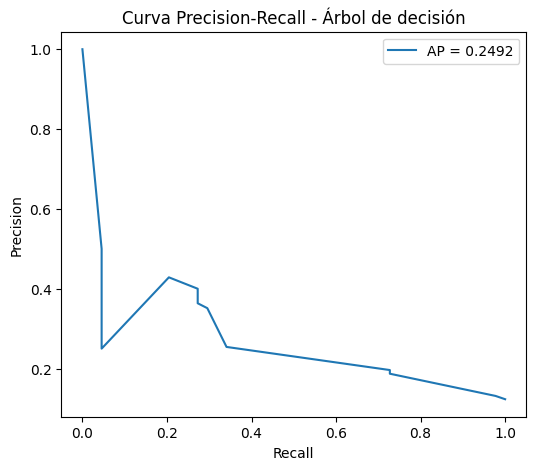

In [46]:
# # =========================================
# BLOQUE 12: ÁRBOL DE DECISIÓN
# =========================================

modelo_arbol = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_arbol.fit(X_train, y_train)

pred_arbol, prob_arbol, tabla_metricas_arbol, tabla_global_arbol = evaluar_modelo(
    modelo_arbol,
    X_test,
    y_test,
    nombre_modelo="Árbol de decisión"
)

In [ ]:
#BLOQUE 12.1. Matriz de confusión del árbol

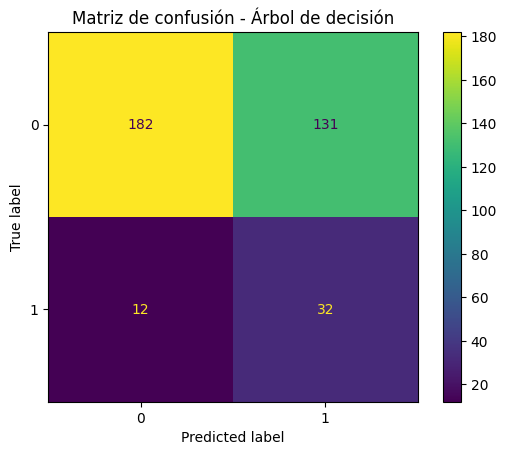

In [38]:
cm = confusion_matrix(y_test, pred_arbol)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

In [47]:
df_resultados_arbol = X_test.copy()
df_resultados_arbol["y_real"] = y_test.values
df_resultados_arbol["y_pred"] = pred_arbol
df_resultados_arbol["prob_consumada"] = prob_arbol

df_resultados_arbol.sort_values("prob_consumada", ascending=False).head(20)

,CUADRANTE,SEXO_VICTIMA,RANGO_DE_EDAD,GIRO_COMERCIO_RED,TIPO_EXTORSION,FRANJA_HORARIA,DIA_SEMANA,FIN_SEMANA,y_real,y_pred,prob_consumada
546,C052,M,36-45 AÑOS,NO APLICA,EXTORSION,MANANA,MIERCOLES,0,0,1,0.968085
51,NO ESP.,M,18-25 AÑOS,NO APLICA,EXTORSION,MADRUGADA,VIERNES,0,1,1,0.968085
304,C102,M,26-35 AÑOS,NO APLICA,EXTORSION,NOCHE,SABADO,1,1,1,0.968085
545,C042,M,56 Y MAS,VETERINARIA,EXTORSION,NOCHE,MIERCOLES,0,0,1,0.968085
219,C132,F,46-55 AÑOS,NO APLICA,PRESENCIAL,TARDE,JUEVES,0,0,1,0.900000
687,C097,M,26-35 AÑOS,NO APLICA,PRESENCIAL,TARDE,LUNES,0,0,1,0.900000
1178,C073,F,36-45 AÑOS,NO APLICA,PRESENCIAL,TARDE,VIERNES,0,0,1,0.900000
439,C071,M,46-55 AÑOS,NO APLICA,PRESENCIAL,TARDE,SABADO,1,0,1,0.900000
35,C104,M,26-35 AÑOS,MECANICO,PRESENCIAL,TARDE,VIERNES,0,1,1,0.803279
1083,C117,M,DESCONOCIDO,DOMICILIO,PRESENCIAL,TARDE,JUEVES,0,0,1,0.803279


In [39]:
#BLOQUE 12.2. Ver probabilidades del árbol
#Esto ayuda mucho para interpretar confianza del modelo
prob_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

df_resultados_arbol = X_test.copy()
df_resultados_arbol["y_real"] = y_test.values
df_resultados_arbol["y_pred"] = pred_arbol
df_resultados_arbol["prob_consumada"] = prob_arbol

df_resultados_arbol.head(10)

,CUADRANTE,SEXO_VICTIMA,RANGO_DE_EDAD,GIRO_COMERCIO_RED,TIPO_EXTORSION,FRANJA_HORARIA,DIA_SEMANA,FIN_SEMANA,y_real,y_pred,prob_consumada
116,C064,M,26-35 AÑOS,OTROS,PRESENCIAL,MANANA,VIERNES,0,1,1,0.803279
1086,C095,F,02-17 AÑOS,DOMICILIO,LLAMADA,TARDE,SABADO,1,0,0,0.171569
120,C131,NP,DESCONOCIDO,NO APLICA,MENSAJE,MADRUGADA,DOMINGO,1,0,0,0.437500
436,C092,M,56 Y MAS,NO APLICA,LLAMADA,NOCHE,VIERNES,0,0,1,0.529652
445,C083,F,36-45 AÑOS,NO APLICA,LLAMADA,TARDE,DOMINGO,1,0,1,0.529652
470,C125,F,56 Y MAS,NO APLICA,LLAMADA,TARDE,SABADO,1,1,1,0.529652
580,C152,M,DESCONOCIDO,NO APLICA,MENSAJE,TARDE,LUNES,0,0,0,0.000000
568,C082,M,36-45 AÑOS,LOCAL DE COMIDA,LLAMADA,TARDE,LUNES,0,0,0,0.171569
140,C152,F,26-35 AÑOS,LOCAL DE SNAKS,LLAMADA,NOCHE,VIERNES,0,0,0,0.000000
821,C098,F,46-55 AÑOS,NO APLICA,LLAMADA,MANANA,DOMINGO,1,0,1,0.529652


In [ ]:
#BLOQUE 12.3. Casos que el árbol ve con mayor riesgo de consumación

In [40]:
df_resultados_arbol.sort_values("prob_consumada", ascending=False).head(20)

,CUADRANTE,SEXO_VICTIMA,RANGO_DE_EDAD,GIRO_COMERCIO_RED,TIPO_EXTORSION,FRANJA_HORARIA,DIA_SEMANA,FIN_SEMANA,y_real,y_pred,prob_consumada
546,C052,M,36-45 AÑOS,NO APLICA,EXTORSION,MANANA,MIERCOLES,0,0,1,0.968085
51,NO ESP.,M,18-25 AÑOS,NO APLICA,EXTORSION,MADRUGADA,VIERNES,0,1,1,0.968085
304,C102,M,26-35 AÑOS,NO APLICA,EXTORSION,NOCHE,SABADO,1,1,1,0.968085
545,C042,M,56 Y MAS,VETERINARIA,EXTORSION,NOCHE,MIERCOLES,0,0,1,0.968085
219,C132,F,46-55 AÑOS,NO APLICA,PRESENCIAL,TARDE,JUEVES,0,0,1,0.900000
687,C097,M,26-35 AÑOS,NO APLICA,PRESENCIAL,TARDE,LUNES,0,0,1,0.900000
1178,C073,F,36-45 AÑOS,NO APLICA,PRESENCIAL,TARDE,VIERNES,0,0,1,0.900000
439,C071,M,46-55 AÑOS,NO APLICA,PRESENCIAL,TARDE,SABADO,1,0,1,0.900000
35,C104,M,26-35 AÑOS,MECANICO,PRESENCIAL,TARDE,VIERNES,0,1,1,0.803279
1083,C117,M,DESCONOCIDO,DOMICILIO,PRESENCIAL,TARDE,JUEVES,0,0,1,0.803279


In [ ]:
#BLOQUE 13. Visualizar el árbol
#Para interpretar las reglas del modelo

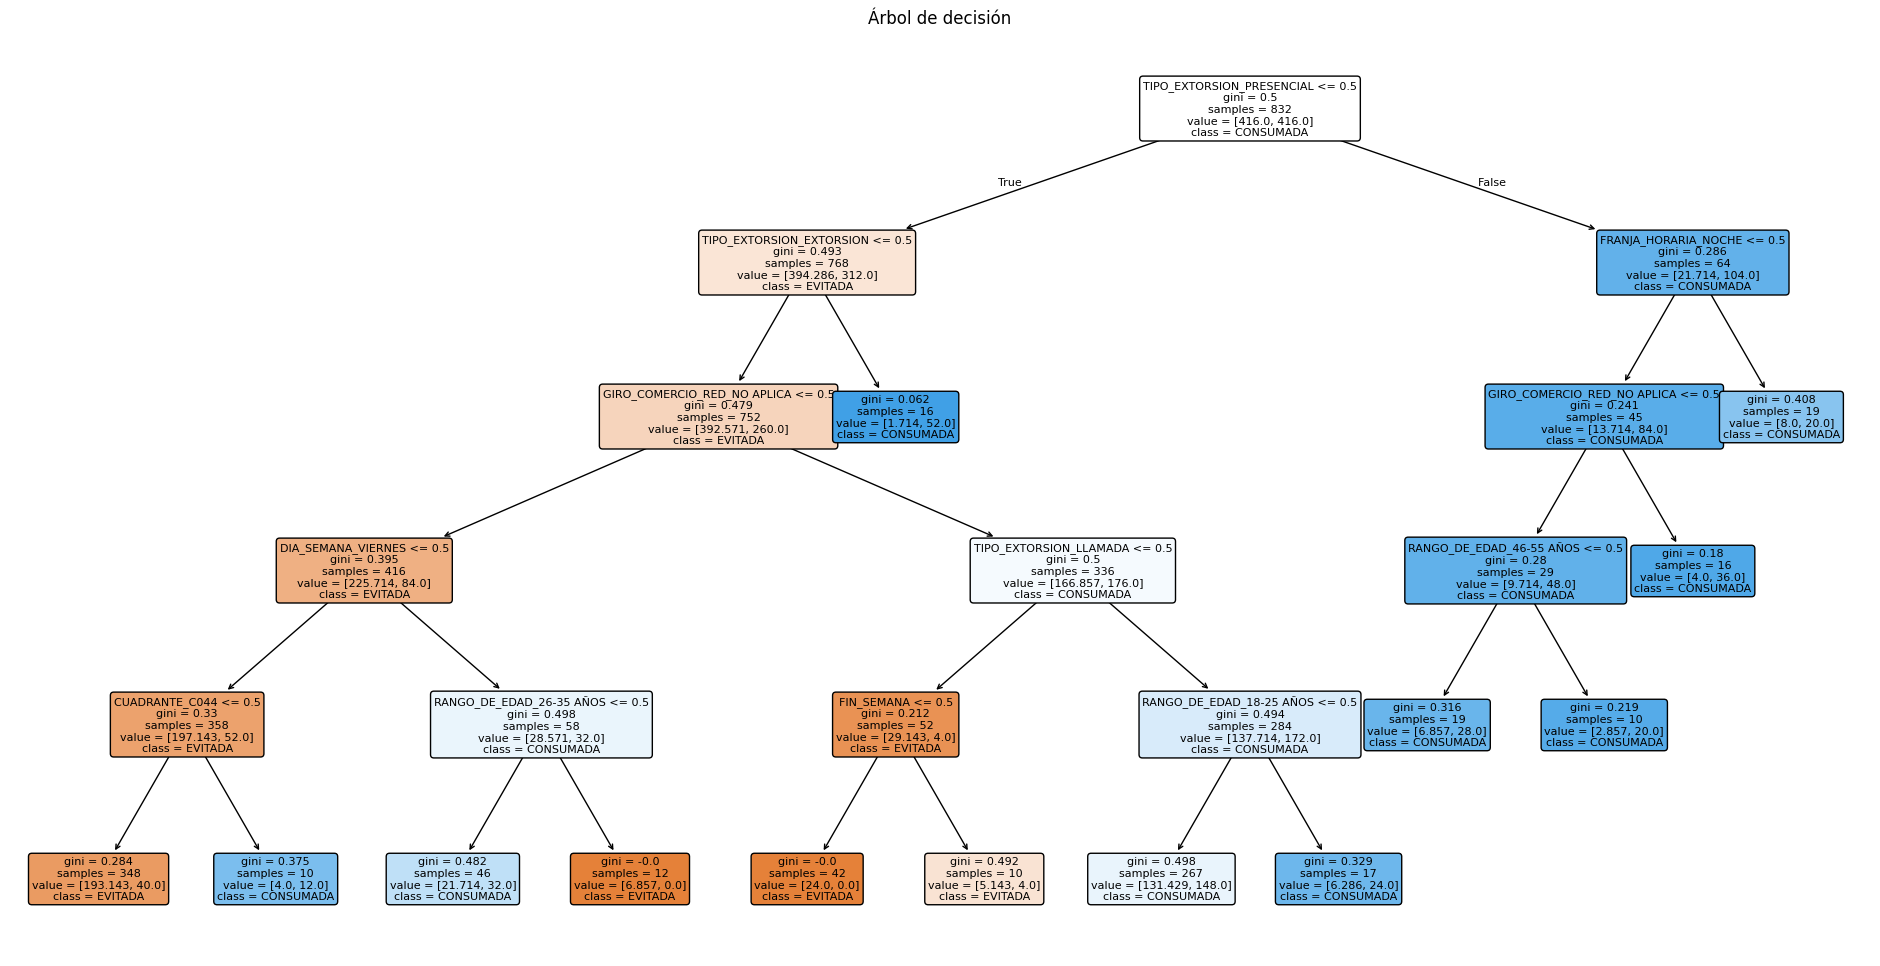

In [48]:
# =========================================
# BLOQUE 13: VISUALIZAR EL ÁRBOL
# =========================================

ohe = modelo_arbol.named_steps["preprocesador"].named_transformers_["cat"].named_steps["onehot"]
nombres_cat = ohe.get_feature_names_out(categoricas)
nombres_finales = list(nombres_cat) + numericas

arbol = modelo_arbol.named_steps["clasificador"]

plt.figure(figsize=(24, 12))
plot_tree(
    arbol,
    feature_names=nombres_finales,
    class_names=["EVITADA", "CONSUMADA"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión")
plt.show()

In [ ]:
#BLOQUE 13.1. Importancia de variables del árbol

In [49]:
importancias_arbol = pd.DataFrame({
    "variable": nombres_finales,
    "importancia": arbol.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias_arbol.head(20))

,variable,importancia
133,TIPO_EXTORSION_EXTORSION,0.255228
137,TIPO_EXTORSION_PRESENCIAL,0.251365
126,GIRO_COMERCIO_RED_NO APLICA,0.152912
134,TIPO_EXTORSION_LLAMADA,0.089639
25,CUADRANTE_C044,0.079388
148,DIA_SEMANA_VIERNES,0.078866
112,RANGO_DE_EDAD_26-35 AÑOS,0.034201
111,RANGO_DE_EDAD_18-25 AÑOS,0.029906
149,FIN_SEMANA,0.020082
140,FRANJA_HORARIA_NOCHE,0.007288


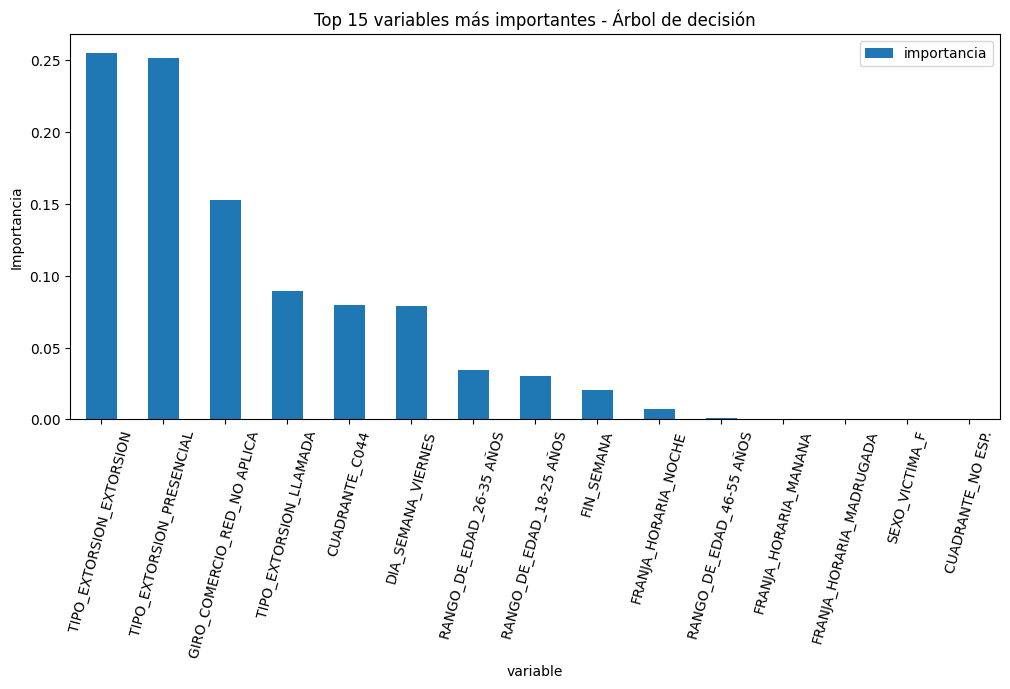

In [50]:
importancias_arbol.head(15).plot(
    x="variable",
    y="importancia",
    kind="bar",
    figsize=(12, 5)
)
plt.title("Top 15 variables más importantes - Árbol de decisión")
plt.ylabel("Importancia")
plt.xticks(rotation=75)
plt.show()


=== RANDOM FOREST ===

Tabla de métricas por clase:


,precision,recall,f1-score,support
0,0.9172,0.8850,0.9008,313.0000
1,0.3455,0.4318,0.3838,44.0000
accuracy,0.8291,0.8291,0.8291,0.8291
macro avg,0.6313,0.6584,0.6423,357.0000
weighted avg,0.8467,0.8291,0.8371,357.0000



Métricas globales:


,metrica,valor
0,accuracy,0.8291
1,balanced_accuracy,0.6584
2,roc_auc,0.7584
3,average_precision,0.3602


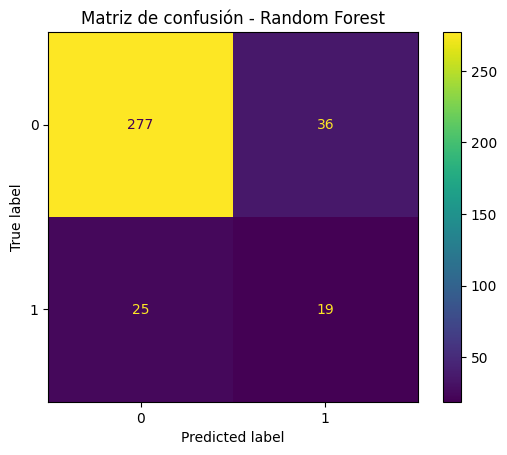

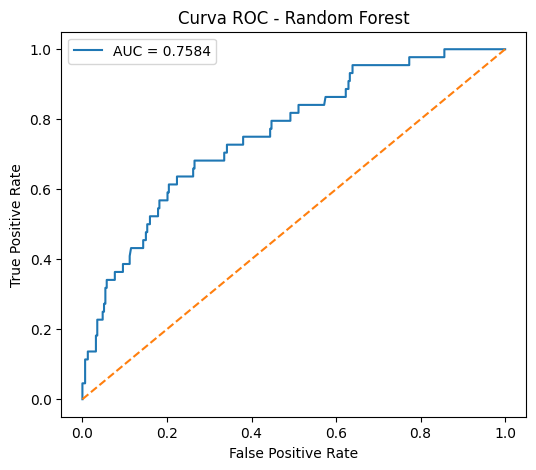

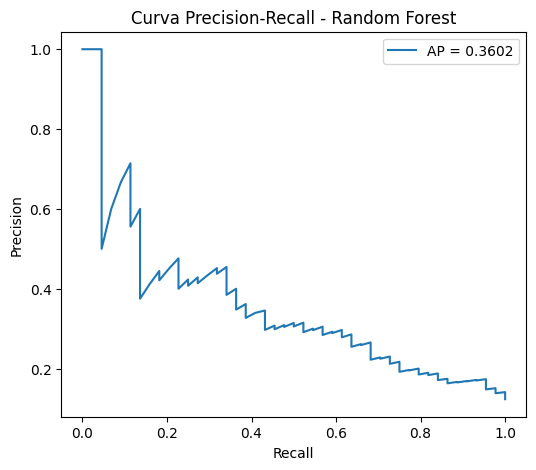

In [51]:
# =========================================
# BLOQUE 14: RANDOM FOREST
# =========================================

modelo_rf = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

pred_rf, prob_rf, tabla_metricas_rf, tabla_global_rf = evaluar_modelo(
    modelo_rf,
    X_test,
    y_test,
    nombre_modelo="Random Forest"
)

In [ ]:
#BLOQUE 14.1. Casos con mayor probabilidad según Random Forest

In [52]:
df_resultados_rf = X_test.copy()
df_resultados_rf["y_real"] = y_test.values
df_resultados_rf["y_pred"] = pred_rf
df_resultados_rf["prob_consumada"] = prob_rf

df_resultados_rf.sort_values("prob_consumada", ascending=False).head(20)

,CUADRANTE,SEXO_VICTIMA,RANGO_DE_EDAD,GIRO_COMERCIO_RED,TIPO_EXTORSION,FRANJA_HORARIA,DIA_SEMANA,FIN_SEMANA,y_real,y_pred,prob_consumada
51,NO ESP.,M,18-25 AÑOS,NO APLICA,EXTORSION,MADRUGADA,VIERNES,0,1,1,0.740068
304,C102,M,26-35 AÑOS,NO APLICA,EXTORSION,NOCHE,SABADO,1,1,1,0.734728
545,C042,M,56 Y MAS,VETERINARIA,EXTORSION,NOCHE,MIERCOLES,0,0,1,0.716383
439,C071,M,46-55 AÑOS,NO APLICA,PRESENCIAL,TARDE,SABADO,1,0,1,0.679823
459,C154,M,18-25 AÑOS,POLLERIA,PRESENCIAL,TARDE,MIERCOLES,0,1,1,0.679714
35,C104,M,26-35 AÑOS,MECANICO,PRESENCIAL,TARDE,VIERNES,0,1,1,0.668762
461,C106,M,36-45 AÑOS,NO APLICA,PRESENCIAL,NOCHE,JUEVES,0,1,1,0.666358
1178,C073,F,36-45 AÑOS,NO APLICA,PRESENCIAL,TARDE,VIERNES,0,0,1,0.661621
546,C052,M,36-45 AÑOS,NO APLICA,EXTORSION,MANANA,MIERCOLES,0,0,1,0.655709
118,C086,F,18-25 AÑOS,OTROS,PRESENCIAL,MADRUGADA,SABADO,1,1,1,0.651287


In [ ]:
#BLOQUE 15. Importancia de variables del Random Forest

In [53]:
ohe_rf = modelo_rf.named_steps["preprocesador"].named_transformers_["cat"].named_steps["onehot"]
nombres_cat_rf = ohe_rf.get_feature_names_out(categoricas)
nombres_finales_rf = list(nombres_cat_rf) + numericas

rf = modelo_rf.named_steps["clasificador"]

importancias_rf = pd.DataFrame({
    "variable": nombres_finales_rf,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias_rf.head(20))

,variable,importancia
137,TIPO_EXTORSION_PRESENCIAL,0.107848
134,TIPO_EXTORSION_LLAMADA,0.107160
133,TIPO_EXTORSION_EXTORSION,0.096294
126,GIRO_COMERCIO_RED_NO APLICA,0.063218
135,TIPO_EXTORSION_MENSAJE,0.055434
140,FRANJA_HORARIA_NOCHE,0.035392
144,DIA_SEMANA_LUNES,0.031943
116,RANGO_DE_EDAD_DESCONOCIDO,0.030796
127,GIRO_COMERCIO_RED_OTROS,0.026011
111,RANGO_DE_EDAD_18-25 AÑOS,0.025274


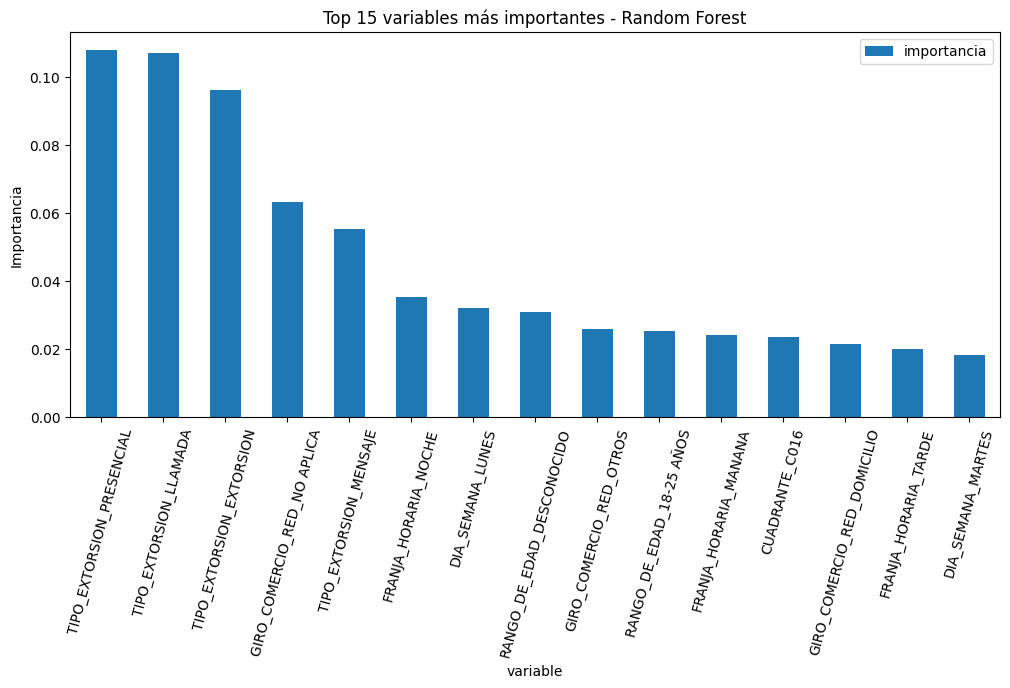

In [54]:
importancias_rf.head(15).plot(
    x="variable",
    y="importancia",
    kind="bar",
    figsize=(12, 5)
)
plt.title("Top 15 variables más importantes - Random Forest")
plt.ylabel("Importancia")
plt.xticks(rotation=75)
plt.show()

In [ ]:
#BLOQUE 15.1. Comparar árbol vs random forest
#Este bloque te ayuda a ver cuál se comporta mejor.

In [55]:
comparacion_global = pd.concat(
    [
        tabla_global_arbol.assign(modelo="Arbol"),
        tabla_global_rf.assign(modelo="RandomForest")
    ],
    ignore_index=True
)

comparacion_global = comparacion_global[["modelo", "metrica", "valor"]]
display(comparacion_global)

,modelo,metrica,valor
0,Arbol,accuracy,0.5994
1,Arbol,balanced_accuracy,0.6544
2,Arbol,roc_auc,0.6868
3,Arbol,average_precision,0.2492
4,RandomForest,accuracy,0.8291
5,RandomForest,balanced_accuracy,0.6584
6,RandomForest,roc_auc,0.7584
7,RandomForest,average_precision,0.3602


In [ ]:
#BLOQUE 15.2. Comparar métricas por clase

In [56]:
tabla_arbol = tabla_metricas_arbol.copy()
tabla_arbol["modelo"] = "Arbol"

tabla_rf = tabla_metricas_rf.copy()
tabla_rf["modelo"] = "RandomForest"

comparacion_clases = pd.concat([tabla_arbol, tabla_rf], axis=0)
display(comparacion_clases)

,precision,recall,f1-score,support,modelo
0,0.9381,0.5815,0.7179,313.0000,Arbol
1,0.1963,0.7273,0.3092,44.0000,Arbol
accuracy,0.5994,0.5994,0.5994,0.5994,Arbol
macro avg,0.5672,0.6544,0.5136,357.0000,Arbol
weighted avg,0.8467,0.5994,0.6676,357.0000,Arbol
0,0.9172,0.8850,0.9008,313.0000,RandomForest
1,0.3455,0.4318,0.3838,44.0000,RandomForest
accuracy,0.8291,0.8291,0.8291,0.8291,RandomForest
macro avg,0.6313,0.6584,0.6423,357.0000,RandomForest
weighted avg,0.8467,0.8291,0.8371,357.0000,RandomForest


In [ ]:
#Siguiente bloque recomendado
#Ajuste de umbral en Random Forest

In [57]:
# =========================================
# BLOQUE 15.3: AJUSTE DE UMBRAL
# =========================================

umbrales = np.arange(0.10, 0.91, 0.05)

resultados_umbral = []

for umbral in umbrales:
    pred_umbral = (prob_rf >= umbral).astype(int)

    reporte = classification_report(y_test, pred_umbral, output_dict=True, zero_division=0)

    resultados_umbral.append({
        "umbral": umbral,
        "precision_clase_1": reporte["1"]["precision"],
        "recall_clase_1": reporte["1"]["recall"],
        "f1_clase_1": reporte["1"]["f1-score"],
        "accuracy": reporte["accuracy"]
    })

df_umbrales = pd.DataFrame(resultados_umbral)
display(df_umbrales)

,umbral,precision_clase_1,recall_clase_1,f1_clase_1,accuracy
0,0.10,0.123249,1.000000,0.219451,0.123249
1,0.15,0.123249,1.000000,0.219451,0.123249
2,0.20,0.123249,1.000000,0.219451,0.123249
3,0.25,0.124646,1.000000,0.221662,0.134454
4,0.30,0.137931,1.000000,0.242424,0.229692
5,0.35,0.169355,0.954545,0.287671,0.417367
6,0.40,0.196429,0.750000,0.311321,0.591036
7,0.45,0.258929,0.659091,0.371795,0.725490
8,0.50,0.345455,0.431818,0.383838,0.829132
9,0.55,0.428571,0.272727,0.333333,0.865546


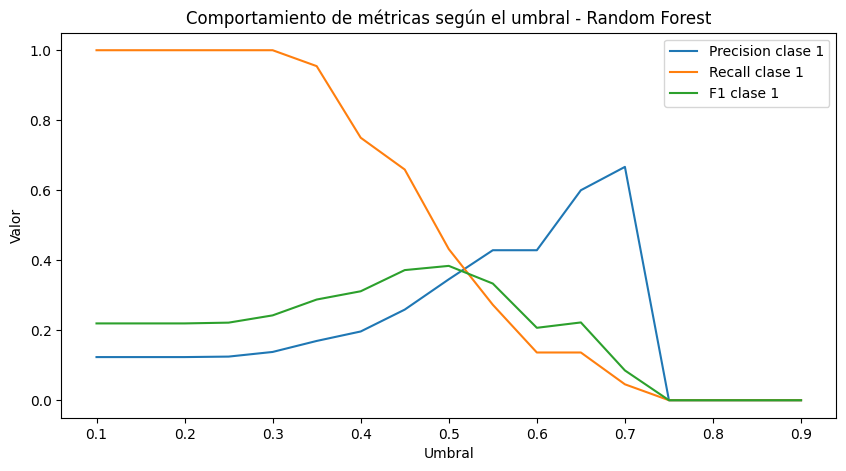

In [58]:
plt.figure(figsize=(10,5))
plt.plot(df_umbrales["umbral"], df_umbrales["precision_clase_1"], label="Precision clase 1")
plt.plot(df_umbrales["umbral"], df_umbrales["recall_clase_1"], label="Recall clase 1")
plt.plot(df_umbrales["umbral"], df_umbrales["f1_clase_1"], label="F1 clase 1")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.title("Comportamiento de métricas según el umbral - Random Forest")
plt.legend()
plt.show()

In [59]:
mejor_f1 = df_umbrales.loc[df_umbrales["f1_clase_1"].idxmax()]
print("Mejor umbral según F1:")
print(mejor_f1)

Mejor umbral según F1:
umbral               0.500000
precision_clase_1    0.345455
recall_clase_1       0.431818
f1_clase_1           0.383838
accuracy             0.829132
Name: 8, dtype: float64


In [ ]:
#Recalcular matriz de confusión con el mejor umbral

Umbral óptimo: 0.50

              precision    recall  f1-score   support

           0     0.9172    0.8850    0.9008       313
           1     0.3455    0.4318    0.3838        44

    accuracy                         0.8291       357
   macro avg     0.6313    0.6584    0.6423       357
weighted avg     0.8467    0.8291    0.8371       357



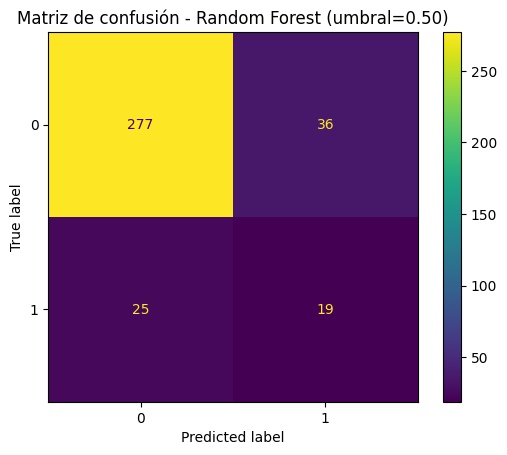

In [60]:
umbral_optimo = mejor_f1["umbral"]

pred_rf_opt = (prob_rf >= umbral_optimo).astype(int)

print(f"Umbral óptimo: {umbral_optimo:.2f}\n")
print(classification_report(y_test, pred_rf_opt, digits=4, zero_division=0))

cm = confusion_matrix(y_test, pred_rf_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de confusión - Random Forest (umbral={umbral_optimo:.2f})")
plt.show()

In [ ]:
#BLOQUE 16. Búsqueda de hiperparámetros para Random Forest

In [71]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

modelo_rf_tuning = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_dist = {
    "clasificador__n_estimators": [100, 200, 300, 500],
    "clasificador__max_depth": [4, 6, 8, 10, None],
    "clasificador__min_samples_split": [2, 5, 10],
    "clasificador__min_samples_leaf": [1, 3, 5, 10],
    "clasificador__max_features": ["sqrt", "log2", None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_rf = RandomizedSearchCV(
    estimator=modelo_rf_tuning,
    param_distributions=param_dist,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

inicio = time.time()
random_rf.fit(X_train, y_train)
fin = time.time()

print("Tiempo total (segundos):", round(fin - inicio, 2))
print("\nMejores parámetros encontrados:")
print(random_rf.best_params_)

print("\nMejor score CV (average_precision):")
print(round(random_rf.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Tiempo total (segundos): 16.8

Mejores parámetros encontrados:
{'clasificador__n_estimators': 100, 'clasificador__min_samples_split': 5, 'clasificador__min_samples_leaf': 1, 'clasificador__max_features': 'log2', 'clasificador__max_depth': 8}

Mejor score CV (average_precision):
0.4282


In [72]:
#BLOQUE 16.1. Evaluar el mejor Random Forest encontrado


=== RANDOM FOREST AJUSTADO ===

Tabla de métricas por clase:


,precision,recall,f1-score,support
0,0.9054,0.9169,0.9111,313.0000
1,0.3500,0.3182,0.3333,44.0000
accuracy,0.8431,0.8431,0.8431,0.8431
macro avg,0.6277,0.6176,0.6222,357.0000
weighted avg,0.8369,0.8431,0.8399,357.0000



Métricas globales:


,metrica,valor
0,accuracy,0.8431
1,balanced_accuracy,0.6176
2,roc_auc,0.7541
3,average_precision,0.3253


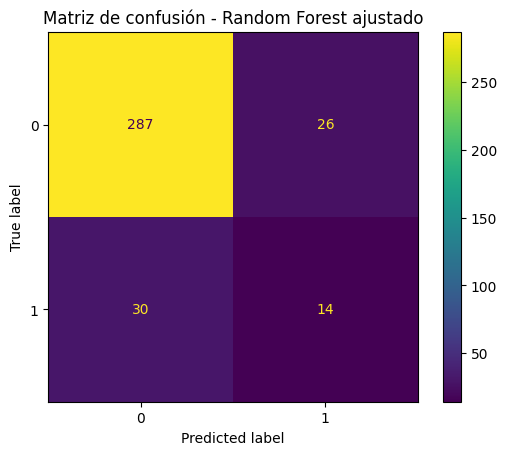

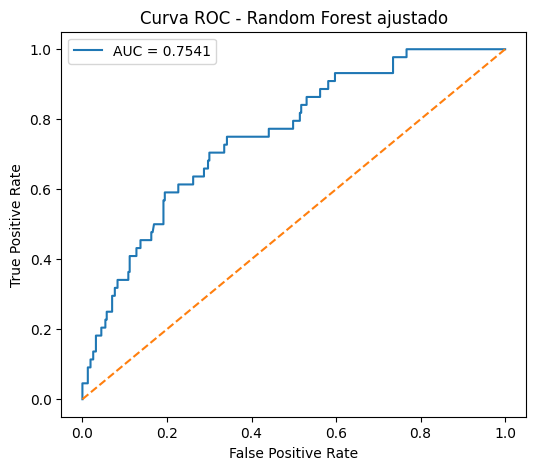

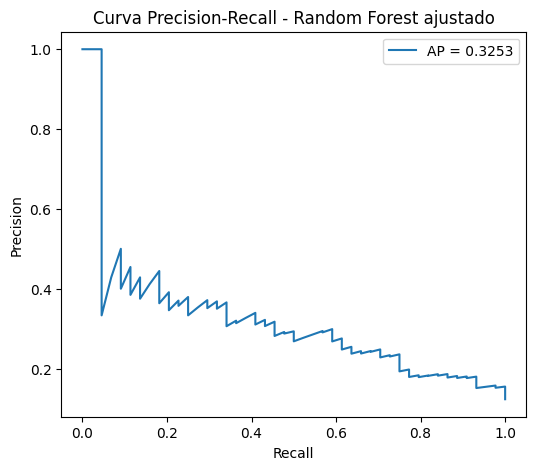

In [73]:
mejor_rf = random_rf.best_estimator_

pred_rf_best, prob_rf_best, tabla_metricas_rf_best, tabla_global_rf_best = evaluar_modelo(
    mejor_rf,
    X_test,
    y_test,
    nombre_modelo="Random Forest ajustado"
)

In [74]:
#BLOQUE 16.2. Comparar baseline vs RF ajustado

In [70]:
comparacion_final = pd.concat(
    [
        tabla_global_rf.assign(modelo="RF_baseline"),
        tabla_global_rf_best.assign(modelo="RF_ajustado")
    ],
    ignore_index=True
)

display(comparacion_final[["modelo", "metrica", "valor"]])

,modelo,metrica,valor
0,RF_baseline,accuracy,0.8291
1,RF_baseline,balanced_accuracy,0.6584
2,RF_baseline,roc_auc,0.7584
3,RF_baseline,average_precision,0.3602
4,RF_ajustado,accuracy,0.8375
5,RF_ajustado,balanced_accuracy,0.6339
6,RF_ajustado,roc_auc,0.7304
7,RF_ajustado,average_precision,0.3280


In [65]:
features = features_explicativas

In [75]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

modelo_rf_tuning = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clasificador__n_estimators": [200, 300],
    "clasificador__max_depth": [6, 8, None],
    "clasificador__min_samples_split": [2, 5],
    "clasificador__min_samples_leaf": [1, 5],
    "clasificador__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=modelo_rf_tuning,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

inicio = time.time()
grid_rf.fit(X_train, y_train)
fin = time.time()

print("Tiempo total (segundos):", round(fin - inicio, 2))
print("\nMejores parámetros encontrados:")
print(grid_rf.best_params_)

print("\nMejor score CV (average_precision):")
print(round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Tiempo total (segundos): 22.81

Mejores parámetros encontrados:
{'clasificador__max_depth': 8, 'clasificador__max_features': 'log2', 'clasificador__min_samples_leaf': 1, 'clasificador__min_samples_split': 5, 'clasificador__n_estimators': 200}

Mejor score CV (average_precision):
0.4088


In [ ]:
#BLOQUE 17. Evaluar el modelo explicativo con el mismo RF baseline

In [76]:
# =========================================
# BLOQUE 17: MODELO EXPLICATIVO
# =========================================

features = features_explicativas
target = "TARGET_CONSUMADA"

X_exp = df_model[features].copy()
y_exp = df_model[target].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp,
    test_size=0.30,
    random_state=42,
    stratify=y_exp
)

categoricas_exp = X_train_exp.select_dtypes(include=["object"]).columns.tolist()
numericas_exp = X_train_exp.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas explicativas:")
print(categoricas_exp)

print("\nVariables numéricas explicativas:")
print(numericas_exp)

Variables categóricas explicativas:
['CUADRANTE', 'JERARQUIA', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'DETENCION_PUESTA_REMISION', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA']

Variables numéricas explicativas:
['FIN_SEMANA']


In [ ]:
#BLOQUE 17.1. Preprocesador para el modelo explicativo

In [77]:
preprocesador_exp = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categoricas_exp),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), numericas_exp)
    ],
    remainder="drop"
)

In [ ]:
BLOQUE 17.2. Random Forest baseline sobre variables explicativas


=== RANDOM FOREST EXPLICATIVO ===

Tabla de métricas por clase:


,precision,recall,f1-score,support
0,0.9747,0.9840,0.9793,313.0000
1,0.8780,0.8182,0.8471,44.0000
accuracy,0.9636,0.9636,0.9636,0.9636
macro avg,0.9264,0.9011,0.9132,357.0000
weighted avg,0.9628,0.9636,0.9630,357.0000



Métricas globales:


,metrica,valor
0,accuracy,0.9636
1,balanced_accuracy,0.9011
2,roc_auc,0.9536
3,average_precision,0.7791


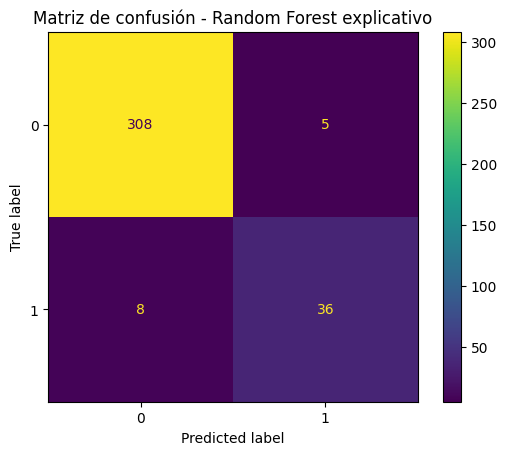

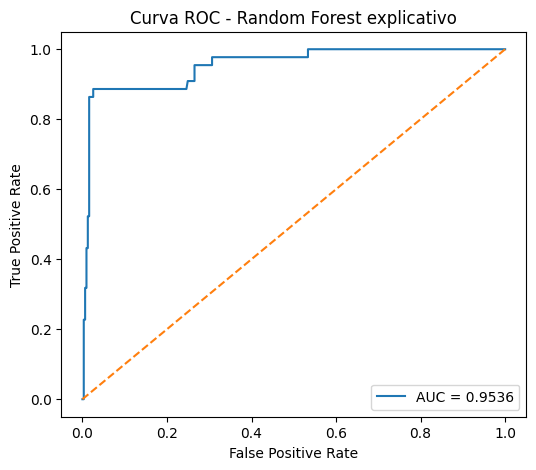

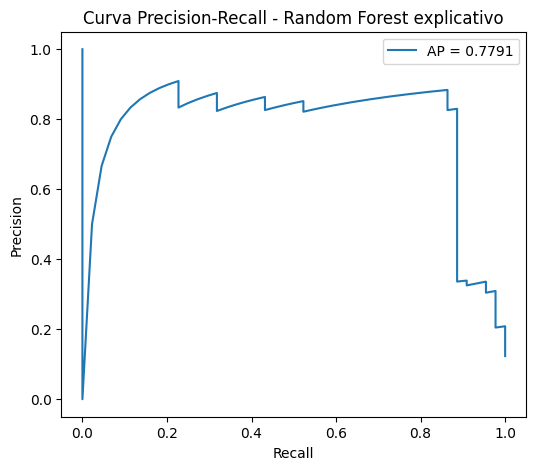

In [78]:
modelo_rf_exp = Pipeline(steps=[
    ("preprocesador", preprocesador_exp),
    ("clasificador", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_rf_exp.fit(X_train_exp, y_train_exp)

pred_rf_exp, prob_rf_exp, tabla_metricas_rf_exp, tabla_global_rf_exp = evaluar_modelo(
    modelo_rf_exp,
    X_test_exp,
    y_test_exp,
    nombre_modelo="Random Forest explicativo"
)

In [ ]:
#BLOQUE 17.3. Comparar RF operativo vs RF explicativo

In [79]:
comparacion_modelos = pd.concat(
    [
        tabla_global_rf.assign(modelo="RF_operativo_baseline"),
        tabla_global_rf_exp.assign(modelo="RF_explicativo_baseline")
    ],
    ignore_index=True
)

display(comparacion_modelos[["modelo", "metrica", "valor"]])

,modelo,metrica,valor
0,RF_operativo_baseline,accuracy,0.8291
1,RF_operativo_baseline,balanced_accuracy,0.6584
2,RF_operativo_baseline,roc_auc,0.7584
3,RF_operativo_baseline,average_precision,0.3602
4,RF_explicativo_baseline,accuracy,0.9636
5,RF_explicativo_baseline,balanced_accuracy,0.9011
6,RF_explicativo_baseline,roc_auc,0.9536
7,RF_explicativo_baseline,average_precision,0.7791


In [ ]:
#BLOQUE 17.4. Comparar métricas por clase

In [80]:
tabla_operativo = tabla_metricas_rf.copy()
tabla_operativo["modelo"] = "RF_operativo_baseline"

tabla_explicativo = tabla_metricas_rf_exp.copy()
tabla_explicativo["modelo"] = "RF_explicativo_baseline"

comparacion_clases = pd.concat([tabla_operativo, tabla_explicativo], axis=0)
display(comparacion_clases)

,precision,recall,f1-score,support,modelo
0,0.9172,0.8850,0.9008,313.0000,RF_operativo_baseline
1,0.3455,0.4318,0.3838,44.0000,RF_operativo_baseline
accuracy,0.8291,0.8291,0.8291,0.8291,RF_operativo_baseline
macro avg,0.6313,0.6584,0.6423,357.0000,RF_operativo_baseline
weighted avg,0.8467,0.8291,0.8371,357.0000,RF_operativo_baseline
0,0.9747,0.9840,0.9793,313.0000,RF_explicativo_baseline
1,0.8780,0.8182,0.8471,44.0000,RF_explicativo_baseline
accuracy,0.9636,0.9636,0.9636,0.9636,RF_explicativo_baseline
macro avg,0.9264,0.9011,0.9132,357.0000,RF_explicativo_baseline
weighted avg,0.9628,0.9636,0.9630,357.0000,RF_explicativo_baseline


In [ ]:
#BLOQUE 18. Ver importancia de variables del modelo explicativo

In [81]:
# =========================================
# BLOQUE 18: IMPORTANCIA DE VARIABLES DEL MODELO EXPLICATIVO
# =========================================

ohe_exp = modelo_rf_exp.named_steps["preprocesador"].named_transformers_["cat"].named_steps["onehot"]
nombres_cat_exp = ohe_exp.get_feature_names_out(categoricas_exp)
nombres_finales_exp = list(nombres_cat_exp) + numericas_exp

rf_exp = modelo_rf_exp.named_steps["clasificador"]

importancias_exp = pd.DataFrame({
    "variable": nombres_finales_exp,
    "importancia": rf_exp.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias_exp.head(20))

,variable,importancia
106,JERARQUIA_ALTO IMPACTO,0.319405
107,JERARQUIA_BAJO IMPACTO,0.278119
136,DETENCION_PUESTA_REMISION_PUESTA,0.058255
135,DETENCION_PUESTA_REMISION_DENUNCIA,0.049850
128,GIRO_COMERCIO_RED_NO APLICA,0.026214
138,TIPO_EXTORSION_EXTORSION,0.025902
139,TIPO_EXTORSION_LLAMADA,0.024418
142,TIPO_EXTORSION_PRESENCIAL,0.020362
140,TIPO_EXTORSION_MENSAJE,0.015776
145,FRANJA_HORARIA_NOCHE,0.010914


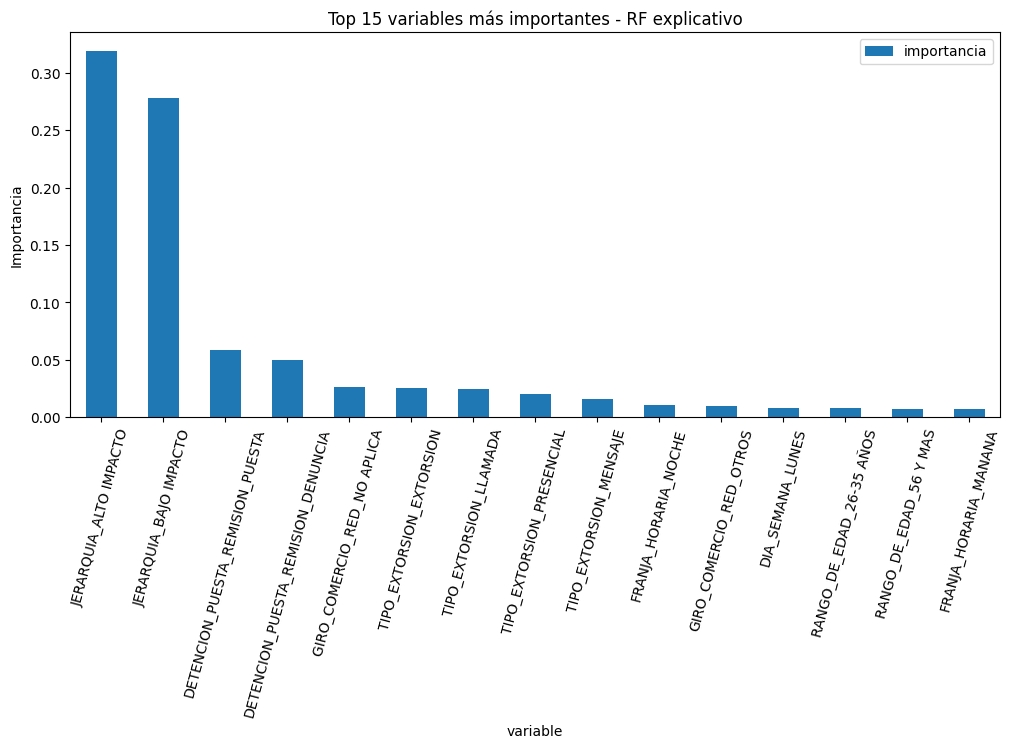

In [82]:
importancias_exp.head(15).plot(
    x="variable",
    y="importancia",
    kind="bar",
    figsize=(12, 5)
)
plt.title("Top 15 variables más importantes - RF explicativo")
plt.ylabel("Importancia")
plt.xticks(rotation=75)
plt.show()

In [ ]:
#BLOQUE 19. Función para comparar subconjuntos de variables

In [83]:
# =========================================
# BLOQUE 19: FUNCIÓN DE COMPARACIÓN DE MODELOS
# =========================================

def correr_rf_y_resumir(df_base, features, nombre_modelo):
    X_tmp = df_base[features].copy()
    y_tmp = df_base["TARGET_CONSUMADA"].copy()

    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp,
        test_size=0.30,
        random_state=42,
        stratify=y_tmp
    )

    categoricas_tmp = X_train_tmp.select_dtypes(include=["object"]).columns.tolist()
    numericas_tmp = X_train_tmp.select_dtypes(include=["int64", "float64"]).columns.tolist()

    preprocesador_tmp = ColumnTransformer(
        transformers=[
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categoricas_tmp),
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]), numericas_tmp)
        ],
        remainder="drop"
    )

    modelo_tmp = Pipeline(steps=[
        ("preprocesador", preprocesador_tmp),
        ("clasificador", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ])

    modelo_tmp.fit(X_train_tmp, y_train_tmp)

    y_pred_tmp = modelo_tmp.predict(X_test_tmp)
    y_prob_tmp = modelo_tmp.predict_proba(X_test_tmp)[:, 1]

    reporte = classification_report(y_test_tmp, y_pred_tmp, output_dict=True, zero_division=0)

    resumen = {
        "modelo": nombre_modelo,
        "n_variables": len(features),
        "precision_clase_1": reporte["1"]["precision"],
        "recall_clase_1": reporte["1"]["recall"],
        "f1_clase_1": reporte["1"]["f1-score"],
        "accuracy": accuracy_score(y_test_tmp, y_pred_tmp),
        "balanced_accuracy": balanced_accuracy_score(y_test_tmp, y_pred_tmp),
        "roc_auc": roc_auc_score(y_test_tmp, y_prob_tmp),
        "average_precision": average_precision_score(y_test_tmp, y_prob_tmp)
    }

    return resumen

In [ ]:
#BLOQUE 19.1. Definir escenarios

In [86]:
# Modelo operativo
vars_operativas = [
    "CUADRANTE",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "GIRO_COMERCIO_RED",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "DIA_SEMANA",
    "FIN_SEMANA"
]

# Operativas + JERARQUIA
vars_mas_jerarquia = vars_operativas + ["JERARQUIA"]

# Operativas + DETENCION
vars_mas_detencion = vars_operativas + ["DETENCION_PUESTA_REMISION"]

# Modelo explicativo completo
vars_explicativas = vars_operativas + ["JERARQUIA", "DETENCION_PUESTA_REMISION"]

In [87]:
#BLOQUE 19.2. Correr la ablación

In [88]:
resultados_ablacion = pd.DataFrame([
    correr_rf_y_resumir(df_model, vars_operativas, "Operativo"),
    correr_rf_y_resumir(df_model, vars_mas_jerarquia, "Operativo + JERARQUIA"),
    correr_rf_y_resumir(df_model, vars_mas_detencion, "Operativo + DETENCION"),
    correr_rf_y_resumir(df_model, vars_explicativas, "Explicativo completo")
])

display(resultados_ablacion.sort_values("f1_clase_1", ascending=False))

,modelo,n_variables,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision
3,Explicativo completo,10,0.883721,0.863636,0.873563,0.969188,0.923831,0.949898,0.785580
1,Operativo + JERARQUIA,9,0.864865,0.727273,0.790123,0.952381,0.855649,0.954255,0.734742
2,Operativo + DETENCION,9,0.500000,0.363636,0.421053,0.876751,0.656259,0.775160,0.473498
0,Operativo,8,0.345455,0.431818,0.383838,0.829132,0.658401,0.758350,0.360208


In [ ]:
#BLOQUE 20. Import para el nuevo enfoque

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

In [ ]:
#BLOQUE 21. Función genérica para comparar escenarios con cualquier algoritmo
#Esta función te va a servir para:
#Regresión Logística
#SVM
#Random Forest
#otros clasificadores

In [90]:
# =========================================
# BLOQUE 21: FUNCIÓN GENÉRICA PARA COMPARAR ALGORITMOS
# =========================================

def correr_modelo_generico(df_base, features, nombre_modelo, clasificador):
    X_tmp = df_base[features].copy()
    y_tmp = df_base["TARGET_CONSUMADA"].copy()

    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp,
        test_size=0.30,
        random_state=42,
        stratify=y_tmp
    )

    categoricas_tmp = X_train_tmp.select_dtypes(include=["object"]).columns.tolist()
    numericas_tmp = X_train_tmp.select_dtypes(include=["int64", "float64"]).columns.tolist()

    preprocesador_tmp = ColumnTransformer(
        transformers=[
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categoricas_tmp),
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]), numericas_tmp)
        ],
        remainder="drop"
    )

    modelo_tmp = Pipeline(steps=[
        ("preprocesador", preprocesador_tmp),
        ("clasificador", clone(clasificador))
    ])

    modelo_tmp.fit(X_train_tmp, y_train_tmp)

    y_pred_tmp = modelo_tmp.predict(X_test_tmp)

    if hasattr(modelo_tmp, "predict_proba"):
        y_prob_tmp = modelo_tmp.predict_proba(X_test_tmp)[:, 1]
    else:
        y_prob_tmp = None

    reporte = classification_report(y_test_tmp, y_pred_tmp, output_dict=True, zero_division=0)

    resumen = {
        "modelo": nombre_modelo,
        "n_variables": len(features),
        "precision_clase_1": reporte["1"]["precision"],
        "recall_clase_1": reporte["1"]["recall"],
        "f1_clase_1": reporte["1"]["f1-score"],
        "accuracy": accuracy_score(y_test_tmp, y_pred_tmp),
        "balanced_accuracy": balanced_accuracy_score(y_test_tmp, y_pred_tmp)
    }

    if y_prob_tmp is not None:
        resumen["roc_auc"] = roc_auc_score(y_test_tmp, y_prob_tmp)
        resumen["average_precision"] = average_precision_score(y_test_tmp, y_prob_tmp)
    else:
        resumen["roc_auc"] = np.nan
        resumen["average_precision"] = np.nan

    return resumen

In [ ]:
#BLOQUE 22. Definir los mismos cuatro escenarios

In [91]:
escenarios = {
    "Operativo": vars_operativas,
    "Operativo + JERARQUIA": vars_mas_jerarquia,
    "Operativo + DETENCION": vars_mas_detencion,
    "Explicativo completo": vars_explicativas
}

for nombre, vars_esc in escenarios.items():
    print(nombre, "->", vars_esc)

Operativo -> ['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA']
Operativo + JERARQUIA -> ['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA', 'JERARQUIA']
Operativo + DETENCION -> ['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA', 'DETENCION_PUESTA_REMISION']
Explicativo completo -> ['CUADRANTE', 'SEXO_VICTIMA', 'RANGO_DE_EDAD', 'GIRO_COMERCIO_RED', 'TIPO_EXTORSION', 'FRANJA_HORARIA', 'DIA_SEMANA', 'FIN_SEMANA', 'JERARQUIA', 'DETENCION_PUESTA_REMISION']


In [ ]:
#BLOQUE 23. Regresión Logística
#Mismo enfoque que usamos antes

In [92]:
logit = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

In [93]:
resultados_logit = pd.DataFrame([
    correr_modelo_generico(df_model, vars_esc, f"Logit - {nombre}", logit)
    for nombre, vars_esc in escenarios.items()
])

display(resultados_logit.sort_values("f1_clase_1", ascending=False))

,modelo,n_variables,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision
1,Logit - Operativo + JERARQUIA,9,0.790698,0.772727,0.781609,0.946779,0.871987,0.922669,0.722532
3,Logit - Explicativo completo,10,0.790698,0.772727,0.781609,0.946779,0.871987,0.940168,0.751462
2,Logit - Operativo + DETENCION,9,0.302632,0.522727,0.383333,0.792717,0.676699,0.749818,0.426312
0,Logit - Operativo,8,0.287356,0.568182,0.381679,0.773109,0.685049,0.716345,0.290615


In [ ]:
#BLOQUE 24. Comparar Logit contra Random Forest
#Aquí vas a poder ver si RF sigue siendo superior.

In [94]:
comparacion_rf_logit = pd.concat([
    resultados_ablacion.assign(algoritmo="RandomForest"),
    resultados_logit.assign(algoritmo="LogisticRegression")
], ignore_index=True)

display(comparacion_rf_logit.sort_values(["modelo", "f1_clase_1"], ascending=[True, False]))

,modelo,n_variables,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision,algoritmo
3,Explicativo completo,10,0.883721,0.863636,0.873563,0.969188,0.923831,0.949898,0.785580,RandomForest
7,Logit - Explicativo completo,10,0.790698,0.772727,0.781609,0.946779,0.871987,0.940168,0.751462,LogisticRegression
4,Logit - Operativo,8,0.287356,0.568182,0.381679,0.773109,0.685049,0.716345,0.290615,LogisticRegression
6,Logit - Operativo + DETENCION,9,0.302632,0.522727,0.383333,0.792717,0.676699,0.749818,0.426312,LogisticRegression
5,Logit - Operativo + JERARQUIA,9,0.790698,0.772727,0.781609,0.946779,0.871987,0.922669,0.722532,LogisticRegression
0,Operativo,8,0.345455,0.431818,0.383838,0.829132,0.658401,0.758350,0.360208,RandomForest
2,Operativo + DETENCION,9,0.500000,0.363636,0.421053,0.876751,0.656259,0.775160,0.473498,RandomForest
1,Operativo + JERARQUIA,9,0.864865,0.727273,0.790123,0.952381,0.855649,0.954255,0.734742,RandomForest


In [95]:
#BLOQUE 25. Instalar XGBoost
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 15.7 MB/s eta 0:00:07
   --- ------------------------------------ 8.4/101.7 MB 25.5 MB/s eta 0:00:04
   ----- ---------------------------------- 14.2/101.7 MB 26.1 MB/s eta 0:00:04
   -------- ------------------------------- 20.4/101.7 MB 27.0 MB/s eta 0:00:04
   ---------- ----------------------------- 27.3/101.7 MB 28.5 MB/s eta 0:00:03
   ------------- -------------------------- 34.9/101.7 MB 29.7 MB/s eta 0:00:03
   ---------------- ----------------------- 41.7/101.7 MB 30.2 MB/s eta 0:00:02
   ------------------- -------------------- 49.0/101.7 MB 31.0 MB/s eta 0:00:02
   --------------------- ------------------ 55.3/101.7 MB 31.2 MB/s eta 0:00:02
   ------------------------ --------------- 62.4/101.7 MB 31.1 MB/s eta 0:00:02
   --------------------------- ------------ 69.5/101.7 MB 31.2 MB/s eta 0:00:02
   ------------------------------ --------- 77.3/10

In [96]:
#BLOQUE 26. Importar XGBoost
from xgboost import XGBClassifier

In [97]:
#BLOQUE 27. Definir clasificador XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [98]:
#BLOQUE 28. Comparar XGBoost en los mismos cuatro escenarios
resultados_xgb = pd.DataFrame([
    correr_modelo_generico(df_model, vars_esc, f"XGB - {nombre}", xgb_model)
    for nombre, vars_esc in escenarios.items()
])

display(resultados_xgb.sort_values("f1_clase_1", ascending=False))

,modelo,n_variables,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision
3,XGB - Explicativo completo,10,0.888889,0.727273,0.800000,0.955182,0.857247,0.935376,0.760569
1,XGB - Operativo + JERARQUIA,9,0.864865,0.727273,0.790123,0.952381,0.855649,0.914537,0.729227
2,XGB - Operativo + DETENCION,9,0.800000,0.272727,0.406780,0.901961,0.631571,0.806128,0.530773
0,XGB - Operativo,8,0.600000,0.136364,0.222222,0.882353,0.561792,0.776721,0.390002


In [99]:
#BLOQUE 29. Comparar RF vs Logit vs XGBoost
comparacion_total = pd.concat([
    resultados_ablacion.assign(algoritmo="RandomForest"),
    resultados_logit.assign(algoritmo="LogisticRegression"),
    resultados_xgb.assign(algoritmo="XGBoost")
], ignore_index=True)

display(comparacion_total.sort_values(["modelo", "f1_clase_1"], ascending=[True, False]))

,modelo,n_variables,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision,algoritmo
3,Explicativo completo,10,0.883721,0.863636,0.873563,0.969188,0.923831,0.949898,0.785580,RandomForest
7,Logit - Explicativo completo,10,0.790698,0.772727,0.781609,0.946779,0.871987,0.940168,0.751462,LogisticRegression
4,Logit - Operativo,8,0.287356,0.568182,0.381679,0.773109,0.685049,0.716345,0.290615,LogisticRegression
6,Logit - Operativo + DETENCION,9,0.302632,0.522727,0.383333,0.792717,0.676699,0.749818,0.426312,LogisticRegression
5,Logit - Operativo + JERARQUIA,9,0.790698,0.772727,0.781609,0.946779,0.871987,0.922669,0.722532,LogisticRegression
0,Operativo,8,0.345455,0.431818,0.383838,0.829132,0.658401,0.758350,0.360208,RandomForest
2,Operativo + DETENCION,9,0.500000,0.363636,0.421053,0.876751,0.656259,0.775160,0.473498,RandomForest
1,Operativo + JERARQUIA,9,0.864865,0.727273,0.790123,0.952381,0.855649,0.954255,0.734742,RandomForest
11,XGB - Explicativo completo,10,0.888889,0.727273,0.800000,0.955182,0.857247,0.935376,0.760569,XGBoost
8,XGB - Operativo,8,0.600000,0.136364,0.222222,0.882353,0.561792,0.776721,0.390002,XGBoost


In [ ]:
#BLOQUE 30. Función para entrenar, evaluar y graficar
#Esta función te genera:
#matriz de confusión
#curva ROC
#curva Precision-Recall
#y devuelve todo guardado para comparar después

In [100]:
from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    accuracy_score,
    balanced_accuracy_score
)

def entrenar_y_graficar(df_base, features, clasificador, nombre_modelo):
    X = df_base[features].copy()
    y = df_base["TARGET_CONSUMADA"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
    numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

    preprocesador = ColumnTransformer(
        transformers=[
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categoricas),
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]), numericas)
        ],
        remainder="drop"
    )

    modelo = Pipeline(steps=[
        ("preprocesador", preprocesador),
        ("clasificador", clone(clasificador))
    ])

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    reporte = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    resumen = {
        "modelo": nombre_modelo,
        "precision_clase_1": reporte["1"]["precision"],
        "recall_clase_1": reporte["1"]["recall"],
        "f1_clase_1": reporte["1"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "average_precision": average_precision_score(y_test, y_prob)
    }

    print(f"\n=== {nombre_modelo} ===")
    print(pd.DataFrame([resumen]).round(4))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {nombre_modelo}")
    plt.legend()
    plt.show()

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_prob):.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curva Precision-Recall - {nombre_modelo}")
    plt.legend()
    plt.show()

    return {
        "nombre": nombre_modelo,
        "modelo": modelo,
        "resumen": resumen,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "fpr": fpr,
        "tpr": tpr,
        "precision_curve": precision,
        "recall_curve": recall
    }

In [ ]:
#BLOQUE 31. Definir los modelos representativos

In [101]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

logit_base = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [ ]:
#BLOQUE 32. Correr los modelos representativos


=== RF - Operativo + JERARQUIA ===
                       modelo  precision_clase_1  recall_clase_1  f1_clase_1  \
0  RF - Operativo + JERARQUIA             0.8649          0.7273      0.7901   

   accuracy  balanced_accuracy  roc_auc  average_precision  
0    0.9524             0.8556   0.9543             0.7347  


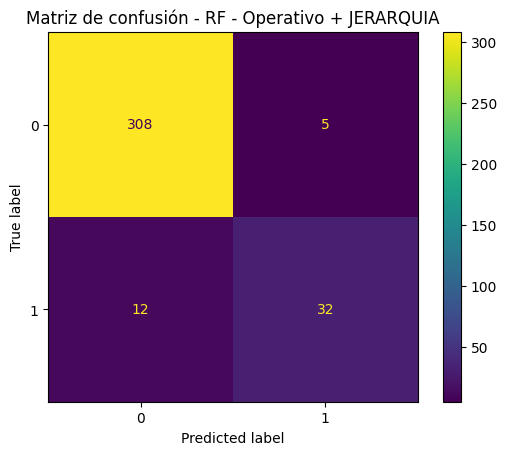

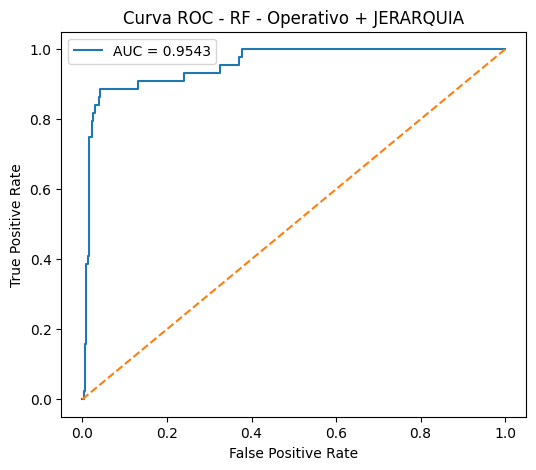

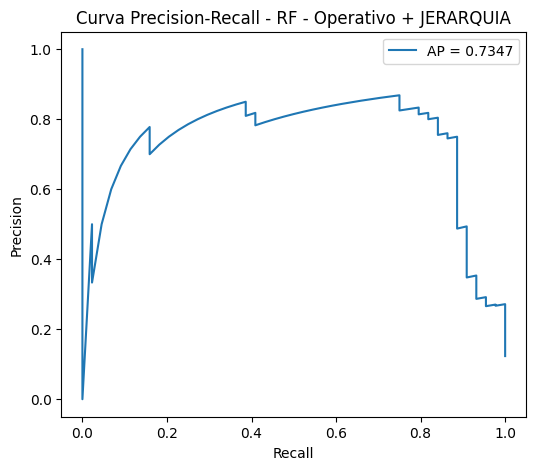


=== RF - Explicativo completo ===
                      modelo  precision_clase_1  recall_clase_1  f1_clase_1  \
0  RF - Explicativo completo             0.8837          0.8636      0.8736   

   accuracy  balanced_accuracy  roc_auc  average_precision  
0    0.9692             0.9238   0.9499             0.7856  


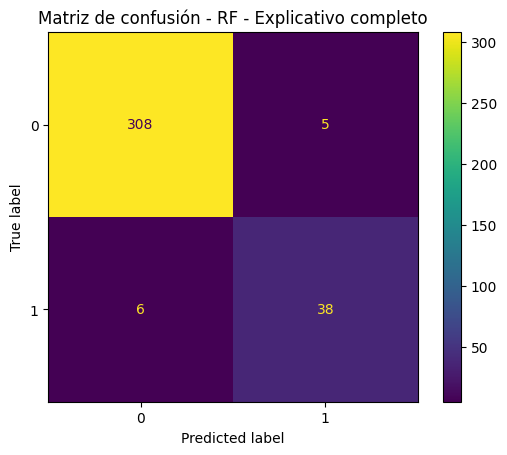

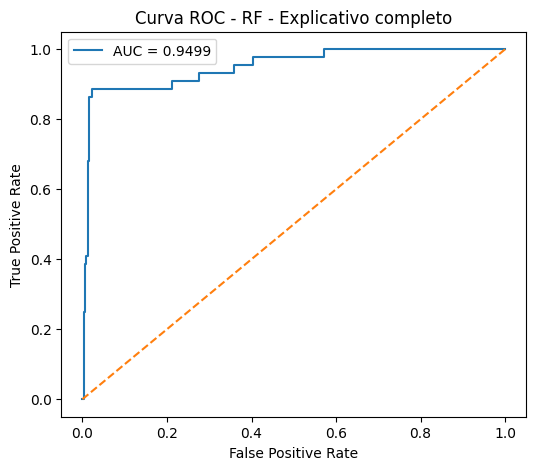

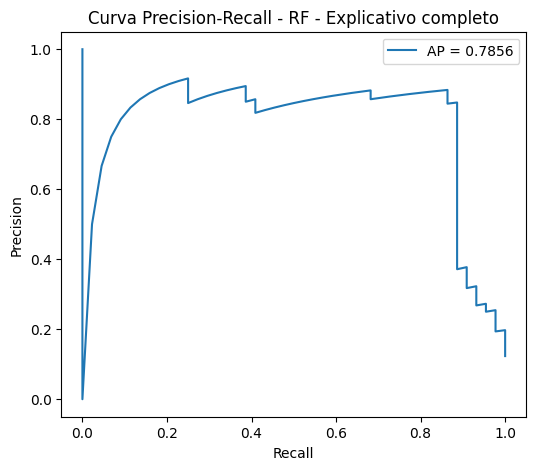


=== Logit - Operativo + JERARQUIA ===
                          modelo  precision_clase_1  recall_clase_1  \
0  Logit - Operativo + JERARQUIA             0.7907          0.7727   

   f1_clase_1  accuracy  balanced_accuracy  roc_auc  average_precision  
0      0.7816    0.9468              0.872   0.9227             0.7225  


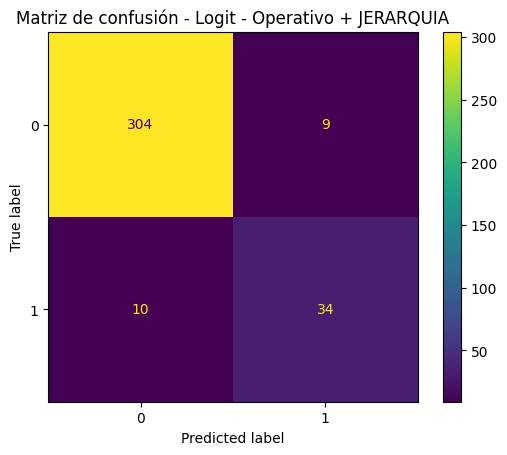

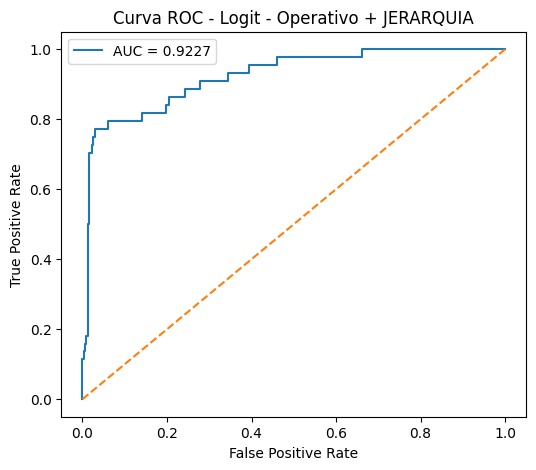

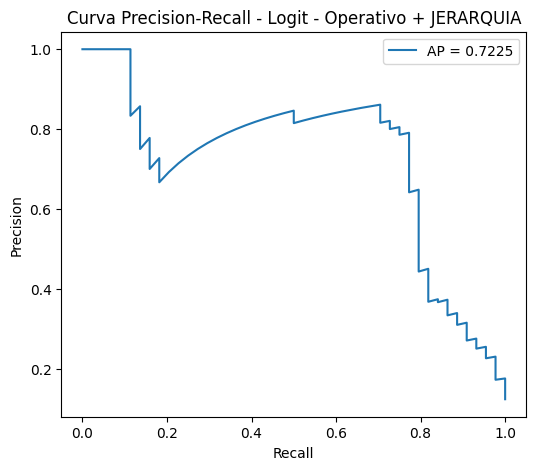


=== XGB - Explicativo completo ===
                       modelo  precision_clase_1  recall_clase_1  f1_clase_1  \
0  XGB - Explicativo completo             0.8889          0.7273         0.8   

   accuracy  balanced_accuracy  roc_auc  average_precision  
0    0.9552             0.8572   0.9354             0.7606  


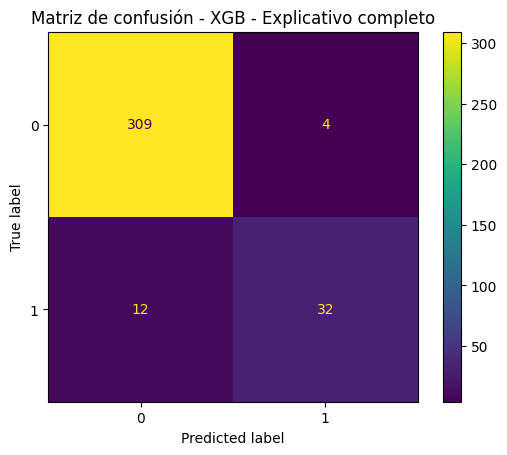

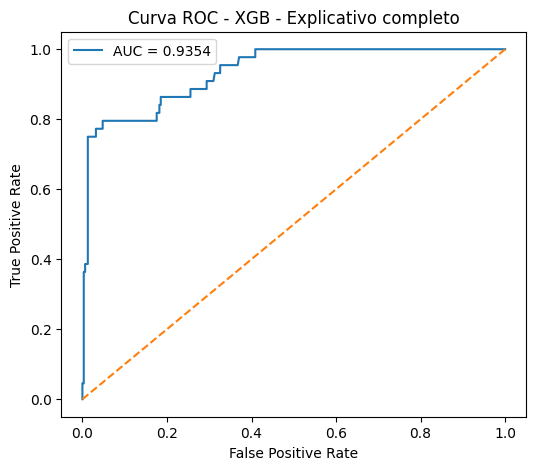

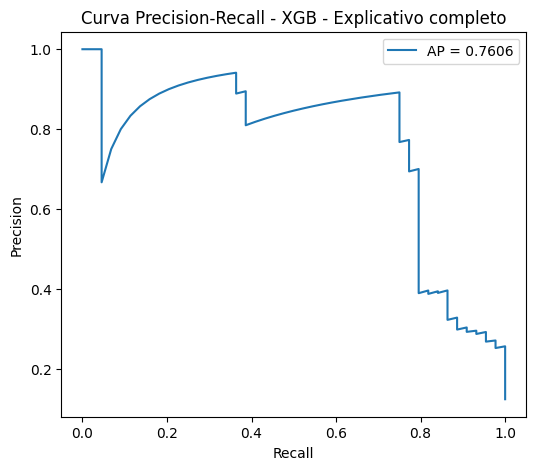

In [102]:
resultados_representativos = {}

resultados_representativos["RF_operativo_jerarquia"] = entrenar_y_graficar(
    df_model,
    vars_mas_jerarquia,
    rf_base,
    "RF - Operativo + JERARQUIA"
)

resultados_representativos["RF_explicativo"] = entrenar_y_graficar(
    df_model,
    vars_explicativas,
    rf_base,
    "RF - Explicativo completo"
)

resultados_representativos["Logit_operativo_jerarquia"] = entrenar_y_graficar(
    df_model,
    vars_mas_jerarquia,
    logit_base,
    "Logit - Operativo + JERARQUIA"
)

resultados_representativos["XGB_explicativo"] = entrenar_y_graficar(
    df_model,
    vars_explicativas,
    xgb_base,
    "XGB - Explicativo completo"
)

In [ ]:
#BLOQUE 33. Tabla resumen de los modelos representativos

In [103]:
tabla_representativos = pd.DataFrame([
    resultados_representativos[k]["resumen"]
    for k in resultados_representativos
]).round(4)

display(tabla_representativos.sort_values("f1_clase_1", ascending=False))

,modelo,precision_clase_1,recall_clase_1,f1_clase_1,accuracy,balanced_accuracy,roc_auc,average_precision
1,RF - Explicativo completo,0.8837,0.8636,0.8736,0.9692,0.9238,0.9499,0.7856
3,XGB - Explicativo completo,0.8889,0.7273,0.8000,0.9552,0.8572,0.9354,0.7606
0,RF - Operativo + JERARQUIA,0.8649,0.7273,0.7901,0.9524,0.8556,0.9543,0.7347
2,Logit - Operativo + JERARQUIA,0.7907,0.7727,0.7816,0.9468,0.8720,0.9227,0.7225


In [ ]:
#BLOQUE 34. Comparación conjunta de curvas ROC
# Este bloque es muy útil para que no queden solo las curvas separadas.

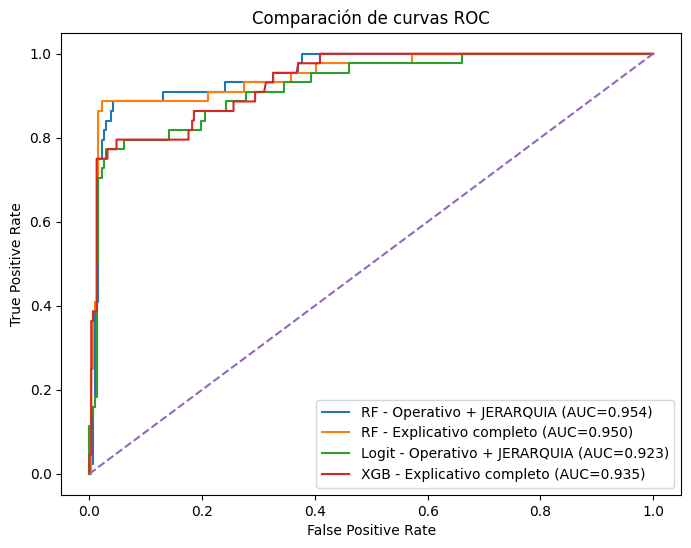

In [104]:
plt.figure(figsize=(8, 6))

for clave, res in resultados_representativos.items():
    plt.plot(
        res["fpr"],
        res["tpr"],
        label=f"{res['nombre']} (AUC={res['resumen']['roc_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.show()

In [ ]:
#BLOQUE 35. Comparación conjunta de curvas Precision-Recall
#Como tu clase positiva es minoritaria, esta gráfica es muy valiosa.

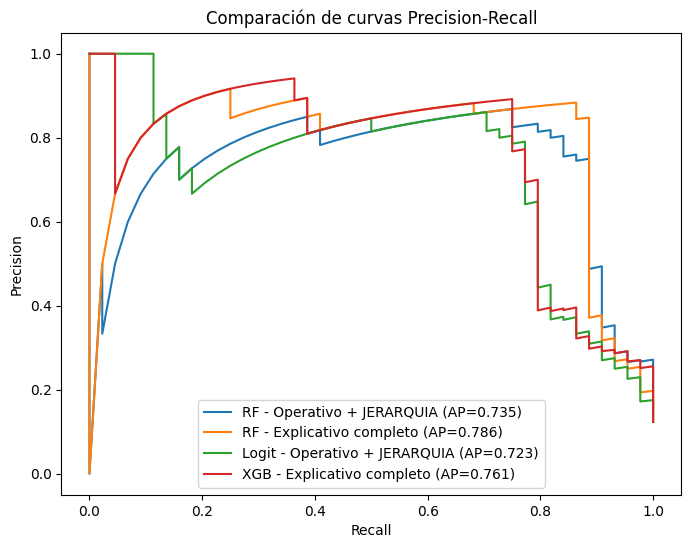

In [105]:
plt.figure(figsize=(8, 6))

for clave, res in resultados_representativos.items():
    plt.plot(
        res["recall_curve"],
        res["precision_curve"],
        label=f"{res['nombre']} (AP={res['resumen']['average_precision']:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparación de curvas Precision-Recall")
plt.legend()
plt.show()

In [ ]:
#BLOQUE 36. Preparar variables para reglas de asociación
#Aquí vamos a usar variables categóricas relevantes y también el resultado del caso.

In [106]:
# =========================================
# BLOQUE 36: PREPARAR DATOS PARA REGLAS
# =========================================

cols_reglas = [
    "CUADRANTE",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "GIRO_COMERCIO_RED",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "JERARQUIA",
    "DELITO2A_PARTE"
]

df_reglas = df_model[cols_reglas].copy()

# Convertimos cada valor en una etiqueta del tipo: COLUMNA=VALOR
for col in cols_reglas:
    df_reglas[col] = col + "=" + df_reglas[col].astype(str)

df_reglas.head()

,CUADRANTE,TIPO_EXTORSION,FRANJA_HORARIA,GIRO_COMERCIO_RED,SEXO_VICTIMA,RANGO_DE_EDAD,JERARQUIA,DELITO2A_PARTE
0,CUADRANTE=C016,TIPO_EXTORSION=LLAMADA,FRANJA_HORARIA=NOCHE,GIRO_COMERCIO_RED=NO APLICA,SEXO_VICTIMA=F,RANGO_DE_EDAD=56 Y MAS,JERARQUIA=ALTO IMPACTO,DELITO2A_PARTE=CONSUMADA
1,CUADRANTE=C062,TIPO_EXTORSION=LLAMADA,FRANJA_HORARIA=MANANA,GIRO_COMERCIO_RED=LOCAL DE COMIDA,SEXO_VICTIMA=F,RANGO_DE_EDAD=36-45 AÑOS,JERARQUIA=BAJO IMPACTO,DELITO2A_PARTE=EVITADA
2,CUADRANTE=C066,TIPO_EXTORSION=LLAMADA,FRANJA_HORARIA=TARDE,GIRO_COMERCIO_RED=LOCAL DE COMIDA,SEXO_VICTIMA=F,RANGO_DE_EDAD=36-45 AÑOS,JERARQUIA=BAJO IMPACTO,DELITO2A_PARTE=EVITADA
3,CUADRANTE=C076,TIPO_EXTORSION=LLAMADA,FRANJA_HORARIA=MANANA,GIRO_COMERCIO_RED=LOCAL DE COMIDA,SEXO_VICTIMA=M,RANGO_DE_EDAD=36-45 AÑOS,JERARQUIA=BAJO IMPACTO,DELITO2A_PARTE=EVITADA
4,CUADRANTE=C014,TIPO_EXTORSION=MENSAJE,FRANJA_HORARIA=TARDE,GIRO_COMERCIO_RED=NO APLICA,SEXO_VICTIMA=F,RANGO_DE_EDAD=26-35 AÑOS,JERARQUIA=BAJO IMPACTO,DELITO2A_PARTE=EVITADA


In [ ]:
#BLOQUE 37. Transformar en transacciones e itemsets frecuentes

In [107]:
# =========================================
# BLOQUE 37: ITEMSETS FRECUENTES
# =========================================

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

transacciones = df_reglas.values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)

df_trans = pd.DataFrame(te_ary, columns=te.columns_)

print("Dimensiones matriz transaccional:", df_trans.shape)
df_trans.head()

Dimensiones matriz transaccional: (1189, 147)


,CUADRANTE=C011,CUADRANTE=C012,CUADRANTE=C013,CUADRANTE=C014,CUADRANTE=C015,CUADRANTE=C016,CUADRANTE=C017,CUADRANTE=C018,CUADRANTE=C021,CUADRANTE=C022,...,RANGO_DE_EDAD=DESCONOCIDO,SEXO_VICTIMA=F,SEXO_VICTIMA=F Y M,SEXO_VICTIMA=M,SEXO_VICTIMA=NP,TIPO_EXTORSION=EXTORSION,TIPO_EXTORSION=LLAMADA,TIPO_EXTORSION=MENSAJE,TIPO_EXTORSION=OTRO,TIPO_EXTORSION=PRESENCIAL
0,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [108]:
# Ajusta min_support si salen demasiadas o muy pocas reglas
itemsets_frecuentes = apriori(
    df_trans,
    min_support=0.03,
    use_colnames=True
).sort_values("support", ascending=False)

display(itemsets_frecuentes.head(20))

,support,itemsets
10,0.888141,(JERARQUIA=BAJO IMPACTO)
1,0.875526,(DELITO2A_PARTE=EVITADA)
37,0.862910,"(DELITO2A_PARTE=EVITADA, JERARQUIA=BAJO IMPACTO)"
19,0.812447,(TIPO_EXTORSION=LLAMADA)
123,0.740118,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=BAJO IMPACTO)"
46,0.732548,"(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=EVITADA)"
224,0.727502,"(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=EVITAD..."
4,0.606392,(FRANJA_HORARIA=TARDE)
72,0.545837,"(FRANJA_HORARIA=TARDE, JERARQUIA=BAJO IMPACTO)"
32,0.539950,"(FRANJA_HORARIA=TARDE, DELITO2A_PARTE=EVITADA)"


In [ ]:
#BLOQUE 38. Generar reglas de asociación

In [109]:
# =========================================
# BLOQUE 38: REGLAS DE ASOCIACIÓN
# =========================================

reglas = association_rules(
    itemsets_frecuentes,
    metric="confidence",
    min_threshold=0.30
).sort_values(["lift", "confidence"], ascending=False)

print("Número total de reglas:", len(reglas))
display(reglas[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

Número total de reglas: 4620


,antecedents,consequents,support,confidence,lift
3228,"(JERARQUIA=ALTO IMPACTO, GIRO_COMERCIO_RED=NO ...","(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=CONSUM...",0.044575,0.746479,9.342772
3227,"(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=CONSUM...","(JERARQUIA=ALTO IMPACTO, GIRO_COMERCIO_RED=NO ...",0.044575,0.557895,9.342772
3230,"(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=C...","(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACTO)",0.044575,0.623529,8.620657
3226,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACTO)","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=C...",0.044575,0.616279,8.620657
3776,(DELITO2A_PARTE=CONSUMADA),"(TIPO_EXTORSION=LLAMADA, SEXO_VICTIMA=M, JERAR...",0.037847,0.304054,7.691921
3766,"(TIPO_EXTORSION=LLAMADA, SEXO_VICTIMA=M, JERAR...",(DELITO2A_PARTE=CONSUMADA),0.037847,0.957447,7.691921
4045,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACT...",(DELITO2A_PARTE=CONSUMADA),0.035324,0.954545,7.668612
4349,"(SEXO_VICTIMA=M, JERARQUIA=ALTO IMPACTO, GIRO_...",(DELITO2A_PARTE=CONSUMADA),0.031960,0.950000,7.632095
3232,(DELITO2A_PARTE=CONSUMADA),"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACT...",0.044575,0.358108,7.603403
3222,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACT...",(DELITO2A_PARTE=CONSUMADA),0.044575,0.946429,7.603403


In [ ]:
#BLOQUE 39. Filtrar reglas cuyo consecuente sea CONSUMADA
#Este bloque es de los más importantes.

In [110]:
# =========================================
# BLOQUE 39: REGLAS HACIA CONSUMADA
# =========================================

reglas_consumada = reglas[
    reglas["consequents"].apply(lambda x: "DELITO2A_PARTE=CONSUMADA" in x)
].copy()

reglas_consumada = reglas_consumada.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

display(reglas_consumada[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20))

,antecedents,consequents,support,confidence,lift
3228,"(JERARQUIA=ALTO IMPACTO, GIRO_COMERCIO_RED=NO ...","(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=CONSUM...",0.044575,0.746479,9.342772
3226,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACTO)","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=C...",0.044575,0.616279,8.620657
3766,"(TIPO_EXTORSION=LLAMADA, SEXO_VICTIMA=M, JERAR...",(DELITO2A_PARTE=CONSUMADA),0.037847,0.957447,7.691921
4045,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACT...",(DELITO2A_PARTE=CONSUMADA),0.035324,0.954545,7.668612
4349,"(SEXO_VICTIMA=M, JERARQUIA=ALTO IMPACTO, GIRO_...",(DELITO2A_PARTE=CONSUMADA),0.031960,0.950000,7.632095
3222,"(TIPO_EXTORSION=LLAMADA, JERARQUIA=ALTO IMPACT...",(DELITO2A_PARTE=CONSUMADA),0.044575,0.946429,7.603403
3775,(JERARQUIA=ALTO IMPACTO),"(TIPO_EXTORSION=LLAMADA, SEXO_VICTIMA=M, DELIT...",0.037847,0.338346,7.590438
1853,(JERARQUIA=ALTO IMPACTO),"(TIPO_EXTORSION=LLAMADA, DELITO2A_PARTE=CONSUM...",0.067283,0.601504,7.528294
3231,(JERARQUIA=ALTO IMPACTO),"(TIPO_EXTORSION=LLAMADA, GIRO_COMERCIO_RED=NO ...",0.044575,0.398496,7.520826
4054,(JERARQUIA=ALTO IMPACTO),"(TIPO_EXTORSION=LLAMADA, FRANJA_HORARIA=TARDE,...",0.035324,0.315789,7.509474


In [ ]:
#BLOQUE 39.1. Filtrar reglas cuyo consecuente sea EVITADA

In [111]:
reglas_evitada = reglas[
    reglas["consequents"].apply(lambda x: "DELITO2A_PARTE=EVITADA" in x)
].copy()

reglas_evitada = reglas_evitada.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

display(reglas_evitada[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20))

,antecedents,consequents,support,confidence,lift
4283,"(TIPO_EXTORSION=MENSAJE, SEXO_VICTIMA=F)","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=E...",0.032801,0.735849,2.073281
4258,"(TIPO_EXTORSION=MENSAJE, SEXO_VICTIMA=F)","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=E...",0.032801,0.735849,2.044216
4278,"(TIPO_EXTORSION=MENSAJE, SEXO_VICTIMA=F, JERAR...","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=E...",0.032801,0.735849,2.044216
4285,"(TIPO_EXTORSION=MENSAJE, JERARQUIA=BAJO IMPACTO)","(GIRO_COMERCIO_RED=NO APLICA, SEXO_VICTIMA=F, ...",0.032801,0.351351,1.989318
4287,(TIPO_EXTORSION=MENSAJE),"(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=E...",0.032801,0.345133,1.982429
4260,(TIPO_EXTORSION=MENSAJE),"(GIRO_COMERCIO_RED=NO APLICA, SEXO_VICTIMA=F, ...",0.032801,0.345133,1.954109
3087,"(TIPO_EXTORSION=LLAMADA, GIRO_COMERCIO_RED=NO ...","(RANGO_DE_EDAD=56 Y MAS, DELITO2A_PARTE=EVITADA)",0.045416,0.335404,1.854861
3093,"(RANGO_DE_EDAD=56 Y MAS, SEXO_VICTIMA=F, JERAR...","(TIPO_EXTORSION=LLAMADA, GIRO_COMERCIO_RED=NO ...",0.045416,0.514286,1.830796
2146,"(TIPO_EXTORSION=MENSAJE, JERARQUIA=BAJO IMPACTO)","(GIRO_COMERCIO_RED=NO APLICA, DELITO2A_PARTE=E...",0.060555,0.648649,1.801970
2147,(TIPO_EXTORSION=MENSAJE),"(JERARQUIA=BAJO IMPACTO, GIRO_COMERCIO_RED=NO ...",0.060555,0.637168,1.795244


In [ ]:
#BLOQUE 39.2. Limpiar formato para leer mejor las reglas

In [112]:
def formatear_frozenset(fs):
    return ", ".join(sorted(list(fs)))

reglas_consumada["antecedentes_txt"] = reglas_consumada["antecedents"].apply(formatear_frozenset)
reglas_consumada["consecuentes_txt"] = reglas_consumada["consequents"].apply(formatear_frozenset)

reglas_evitada["antecedentes_txt"] = reglas_evitada["antecedents"].apply(formatear_frozenset)
reglas_evitada["consecuentes_txt"] = reglas_evitada["consequents"].apply(formatear_frozenset)

display(
    reglas_consumada[
        ["antecedentes_txt", "consecuentes_txt", "support", "confidence", "lift"]
    ].head(15)
)

display(
    reglas_evitada[
        ["antecedentes_txt", "consecuentes_txt", "support", "confidence", "lift"]
    ].head(15)
)

,antecedentes_txt,consecuentes_txt,support,confidence,lift
3228,"GIRO_COMERCIO_RED=NO APLICA, JERARQUIA=ALTO IM...","DELITO2A_PARTE=CONSUMADA, TIPO_EXTORSION=LLAMADA",0.044575,0.746479,9.342772
3226,"JERARQUIA=ALTO IMPACTO, TIPO_EXTORSION=LLAMADA","DELITO2A_PARTE=CONSUMADA, GIRO_COMERCIO_RED=NO...",0.044575,0.616279,8.620657
3766,"JERARQUIA=ALTO IMPACTO, SEXO_VICTIMA=M, TIPO_E...",DELITO2A_PARTE=CONSUMADA,0.037847,0.957447,7.691921
4045,"FRANJA_HORARIA=TARDE, JERARQUIA=ALTO IMPACTO, ...",DELITO2A_PARTE=CONSUMADA,0.035324,0.954545,7.668612
4349,"GIRO_COMERCIO_RED=NO APLICA, JERARQUIA=ALTO IM...",DELITO2A_PARTE=CONSUMADA,0.031960,0.950000,7.632095
3222,"GIRO_COMERCIO_RED=NO APLICA, JERARQUIA=ALTO IM...",DELITO2A_PARTE=CONSUMADA,0.044575,0.946429,7.603403
3775,JERARQUIA=ALTO IMPACTO,"DELITO2A_PARTE=CONSUMADA, SEXO_VICTIMA=M, TIPO...",0.037847,0.338346,7.590438
1853,JERARQUIA=ALTO IMPACTO,"DELITO2A_PARTE=CONSUMADA, TIPO_EXTORSION=LLAMADA",0.067283,0.601504,7.528294
3231,JERARQUIA=ALTO IMPACTO,"DELITO2A_PARTE=CONSUMADA, GIRO_COMERCIO_RED=NO...",0.044575,0.398496,7.520826
4054,JERARQUIA=ALTO IMPACTO,"DELITO2A_PARTE=CONSUMADA, FRANJA_HORARIA=TARDE...",0.035324,0.315789,7.509474


,antecedentes_txt,consecuentes_txt,support,confidence,lift
4283,"SEXO_VICTIMA=F, TIPO_EXTORSION=MENSAJE","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.735849,2.073281
4258,"SEXO_VICTIMA=F, TIPO_EXTORSION=MENSAJE","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.735849,2.044216
4278,"JERARQUIA=BAJO IMPACTO, SEXO_VICTIMA=F, TIPO_E...","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.735849,2.044216
4285,"JERARQUIA=BAJO IMPACTO, TIPO_EXTORSION=MENSAJE","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.351351,1.989318
4287,TIPO_EXTORSION=MENSAJE,"DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.345133,1.982429
4260,TIPO_EXTORSION=MENSAJE,"DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.032801,0.345133,1.954109
3087,"GIRO_COMERCIO_RED=NO APLICA, JERARQUIA=BAJO IM...","DELITO2A_PARTE=EVITADA, RANGO_DE_EDAD=56 Y MAS",0.045416,0.335404,1.854861
3093,"JERARQUIA=BAJO IMPACTO, RANGO_DE_EDAD=56 Y MAS...","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.045416,0.514286,1.830796
2146,"JERARQUIA=BAJO IMPACTO, TIPO_EXTORSION=MENSAJE","DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.060555,0.648649,1.801970
2147,TIPO_EXTORSION=MENSAJE,"DELITO2A_PARTE=EVITADA, GIRO_COMERCIO_RED=NO A...",0.060555,0.637168,1.795244


In [ ]:
#PARTE 2. CLUSTERING CON K-MODES
#Aquí no vamos a meter el resultado del caso dentro del clustering.
#Eso es importante porque queremos que los clusters salgan de la estructura natural de los datos, y luego ver cómo se comporta DELITO2A_PARTE dentro de cada cluster.

In [ ]:
#BLOQUE 40. Seleccionar variables para clustering

In [113]:
# =========================================
# BLOQUE 40: VARIABLES PARA CLUSTERING
# =========================================

cols_cluster = [
    "CUADRANTE",
    "TIPO_EXTORSION",
    "FRANJA_HORARIA",
    "GIRO_COMERCIO_RED",
    "SEXO_VICTIMA",
    "RANGO_DE_EDAD",
    "JERARQUIA"
]

df_cluster = df_model[cols_cluster].fillna("DESCONOCIDO").copy()

print(df_cluster.shape)
df_cluster.head()

(1189, 7)


,CUADRANTE,TIPO_EXTORSION,FRANJA_HORARIA,GIRO_COMERCIO_RED,SEXO_VICTIMA,RANGO_DE_EDAD,JERARQUIA
0,C016,LLAMADA,NOCHE,NO APLICA,F,56 Y MAS,ALTO IMPACTO
1,C062,LLAMADA,MANANA,LOCAL DE COMIDA,F,36-45 AÑOS,BAJO IMPACTO
2,C066,LLAMADA,TARDE,LOCAL DE COMIDA,F,36-45 AÑOS,BAJO IMPACTO
3,C076,LLAMADA,MANANA,LOCAL DE COMIDA,M,36-45 AÑOS,BAJO IMPACTO
4,C014,MENSAJE,TARDE,NO APLICA,F,26-35 AÑOS,BAJO IMPACTO


In [ ]:
#BLOQUE 41. Buscar número de clusters con costo K-Modes
#Vamos a evaluar varios valores de k.

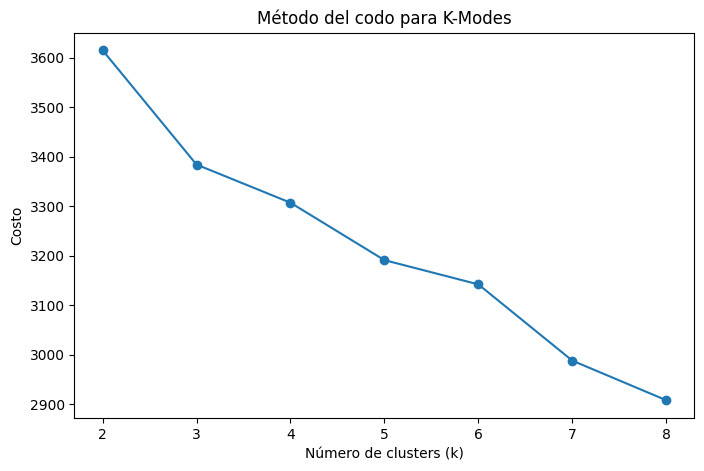

k=2, costo=3615.0
k=3, costo=3384.0
k=4, costo=3307.0
k=5, costo=3191.0
k=6, costo=3142.0
k=7, costo=2988.0
k=8, costo=2908.0


In [114]:
# =========================================
# BLOQUE 41: ELEGIR K
# =========================================

from kmodes.kmodes import KModes

costos = []
rangos_k = range(2, 9)

for k in rangos_k:
    km = KModes(
        n_clusters=k,
        init="Huang",
        n_init=5,
        verbose=0,
        random_state=42
    )
    km.fit(df_cluster)
    costos.append(km.cost_)

plt.figure(figsize=(8, 5))
plt.plot(list(rangos_k), costos, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Costo")
plt.title("Método del codo para K-Modes")
plt.show()

for k, c in zip(rangos_k, costos):
    print(f"k={k}, costo={c}")

In [ ]:
#BLOQUE 42. Ajustar K-Modes con el k elegido
#Aquí te dejo k=4 como punto de partida.
#Si tu gráfica muestra mejor otro valor, lo cambias.

In [115]:
# =========================================
# BLOQUE 42: AJUSTAR K-MODES
# =========================================

k_final = 4

km_final = KModes(
    n_clusters=k_final,
    init="Huang",
    n_init=10,
    verbose=1,
    random_state=42
)

clusters = km_final.fit_predict(df_cluster)

df_model["CLUSTER"] = clusters

print(df_model["CLUSTER"].value_counts().sort_index())

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 411, cost: 3307.0
Run 1, iteration: 2/100, moves: 5, cost: 3307.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 143, cost: 3318.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 330, cost: 3381.0
Run 3, iteration: 2/100, moves: 38, cost: 3381.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 290, cost: 3320.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 196, cost: 3442.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 6, iteration: 1/100, moves: 91, cost: 3449.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 7, iteration: 1/100, moves: 373, cost: 3

In [ ]:
#BLOQUE 43. Distribución del resultado por cluster

In [116]:
# =========================================
# BLOQUE 43: CLUSTER VS RESULTADO
# =========================================

tabla_cluster_resultado = pd.crosstab(
    df_model["CLUSTER"],
    df_model["DELITO2A_PARTE"],
    normalize="index"
) * 100

tabla_cluster_resultado = tabla_cluster_resultado.round(2)

display(tabla_cluster_resultado)

DELITO2A_PARTE,CONSUMADA,EVITADA
CLUSTER,,
0,10.96,89.04
1,11.29,88.71
2,17.20,82.80
3,15.19,84.81


In [ ]:
#BLOQUE 44. Tamaño de cada cluster

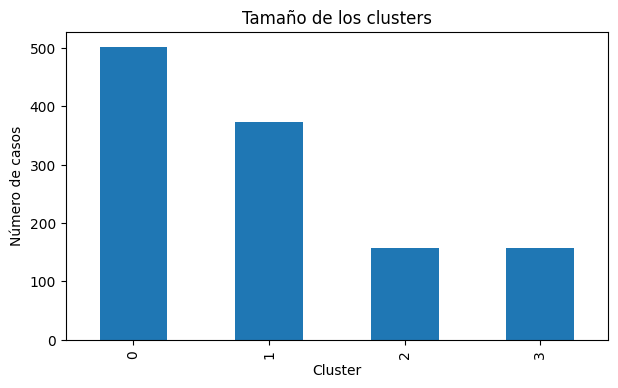

In [117]:
df_model["CLUSTER"].value_counts().sort_index().plot(kind="bar", figsize=(7,4))
plt.title("Tamaño de los clusters")
plt.ylabel("Número de casos")
plt.xlabel("Cluster")
plt.show()

In [ ]:
#BLOQUE 45. Perfil de cada cluster
#Este es uno de los bloques más importantes, porque aquí describes cada tipología.

In [118]:
# =========================================
# BLOQUE 45: PERFIL DE CADA CLUSTER
# =========================================

for c in sorted(df_model["CLUSTER"].unique()):
    print(f"\n================ CLUSTER {c} ================\n")
    
    sub = df_model[df_model["CLUSTER"] == c]
    print("Tamaño:", len(sub))
    
    print("\nResultado:")
    print((sub["DELITO2A_PARTE"].value_counts(normalize=True) * 100).round(2))
    
    print("\nTipo de extorsión:")
    print((sub["TIPO_EXTORSION"].value_counts(normalize=True) * 100).round(2).head(5))
    
    print("\nFranja horaria:")
    print((sub["FRANJA_HORARIA"].value_counts(normalize=True) * 100).round(2).head(5))
    
    print("\nCuadrantes más frecuentes:")
    print(sub["CUADRANTE"].value_counts().head(5))
    
    print("\nGiros comerciales más frecuentes:")
    print(sub["GIRO_COMERCIO_RED"].value_counts().head(5))
    
    print("\nSexo víctima:")
    print((sub["SEXO_VICTIMA"].value_counts(normalize=True) * 100).round(2))
    
    print("\nRango de edad:")
    print((sub["RANGO_DE_EDAD"].value_counts(normalize=True) * 100).round(2).head(5))
    
    print("\nJerarquía:")
    print((sub["JERARQUIA"].value_counts(normalize=True) * 100).round(2))


================ CLUSTER 0 ================

Tamaño: 502

Resultado:
DELITO2A_PARTE
EVITADA      89.04
CONSUMADA    10.96
Name: proportion, dtype: float64

Tipo de extorsión:
TIPO_EXTORSION
LLAMADA       78.69
MENSAJE       11.55
PRESENCIAL     7.77
EXTORSION      1.39
OTRO           0.60
Name: proportion, dtype: float64

Franja horaria:
FRANJA_HORARIA
TARDE        68.13
MANANA       17.53
NOCHE        11.95
MADRUGADA     2.39
Name: proportion, dtype: float64

Cuadrantes más frecuentes:
CUADRANTE
C088    18
C146    12
C073    11
C083    11
C095    11
Name: count, dtype: int64

Giros comerciales más frecuentes:
GIRO_COMERCIO_RED
NO APLICA          234
OTROS              105
DOMICILIO           42
LOCAL DE COMIDA     34
MECANICO            15
Name: count, dtype: int64

Sexo víctima:
SEXO_VICTIMA
F        77.29
M        22.31
F Y M     0.40
Name: proportion, dtype: float64

Rango de edad:
RANGO_DE_EDAD
26-35 AÑOS     38.45
36-45 AÑOS     24.50
46-55 AÑOS     13.75
18-25 AÑOS     12.75
DE

In [ ]:
#BLOQUE 46. Tabla resumen por cluster

In [119]:
# =========================================
# BLOQUE 46: RESUMEN ESTRUCTURADO DE CLUSTERS
# =========================================

resumen_clusters = []

for c in sorted(df_model["CLUSTER"].unique()):
    sub = df_model[df_model["CLUSTER"] == c]
    
    resumen_clusters.append({
        "cluster": c,
        "n_casos": len(sub),
        "pct_consumada": round((sub["DELITO2A_PARTE"] == "CONSUMADA").mean() * 100, 2),
        "tipo_extorsion_top": sub["TIPO_EXTORSION"].mode()[0],
        "franja_top": sub["FRANJA_HORARIA"].mode()[0],
        "cuadrante_top": sub["CUADRANTE"].mode()[0],
        "giro_top": sub["GIRO_COMERCIO_RED"].mode()[0],
        "sexo_top": sub["SEXO_VICTIMA"].mode()[0],
        "edad_top": sub["RANGO_DE_EDAD"].mode()[0],
        "jerarquia_top": sub["JERARQUIA"].mode()[0]
    })

resumen_clusters = pd.DataFrame(resumen_clusters)
display(resumen_clusters)

,cluster,n_casos,pct_consumada,tipo_extorsion_top,franja_top,cuadrante_top,giro_top,sexo_top,edad_top,jerarquia_top
0,0,502,10.96,LLAMADA,TARDE,C088,NO APLICA,F,26-35 AÑOS,BAJO IMPACTO
1,1,372,11.29,LLAMADA,TARDE,C131,OTROS,M,46-55 AÑOS,BAJO IMPACTO
2,2,157,17.20,LLAMADA,NOCHE,NO ESP.,NO APLICA,M,DESCONOCIDO,BAJO IMPACTO
3,3,158,15.19,LLAMADA,TARDE,C021,NO APLICA,F,56 Y MAS,BAJO IMPACTO


In [ ]:
#BLOQUE 47. Métricas globales del clustering

In [120]:
# =========================================
# BLOQUE 47: MÉTRICAS GLOBALES DEL CLUSTERING
# =========================================

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Convertimos las variables categóricas del clustering a dummies
X_cluster_dummy = pd.get_dummies(df_cluster.astype(str))

# Métricas internas
silhouette = silhouette_score(X_cluster_dummy, df_model["CLUSTER"], metric="hamming")
davies_bouldin = davies_bouldin_score(X_cluster_dummy, df_model["CLUSTER"])
calinski = calinski_harabasz_score(X_cluster_dummy, df_model["CLUSTER"])

metricas_cluster_global = pd.DataFrame({
    "metrica": [
        "n_clusters",
        "cost_kmodes",
        "silhouette_hamming",
        "davies_bouldin",
        "calinski_harabasz"
    ],
    "valor": [
        k_final,
        km_final.cost_,
        silhouette,
        davies_bouldin,
        calinski
    ]
})

display(metricas_cluster_global.round(4))

,metrica,valor
0,n_clusters,4.0000
1,cost_kmodes,3259.0000
2,silhouette_hamming,0.0869
3,davies_bouldin,3.1367
4,calinski_harabasz,62.4815


In [ ]:
#BLOQUE 48. Tabla de métricas por cluster
#Esta tabla sí te sirve mucho para el reporte.

In [121]:
# =========================================
# BLOQUE 48: MÉTRICAS POR CLUSTER
# =========================================

metricas_por_cluster = []

for c in sorted(df_model["CLUSTER"].unique()):
    sub = df_model[df_model["CLUSTER"] == c].copy()
    
    n = len(sub)
    pct_total = n / len(df_model) * 100
    
    pct_consumada = (sub["DELITO2A_PARTE"] == "CONSUMADA").mean() * 100
    pct_evitada = (sub["DELITO2A_PARTE"] == "EVITADA").mean() * 100
    
    pureza = max(pct_consumada, pct_evitada)
    
    metricas_por_cluster.append({
        "cluster": c,
        "n_casos": n,
        "pct_total": round(pct_total, 2),
        "pct_consumada": round(pct_consumada, 2),
        "pct_evitada": round(pct_evitada, 2),
        "pureza_resultado": round(pureza, 2),
        "tipo_extorsion_top": sub["TIPO_EXTORSION"].mode()[0],
        "franja_top": sub["FRANJA_HORARIA"].mode()[0],
        "cuadrante_top": sub["CUADRANTE"].mode()[0],
        "giro_top": sub["GIRO_COMERCIO_RED"].mode()[0],
        "sexo_top": sub["SEXO_VICTIMA"].mode()[0],
        "edad_top": sub["RANGO_DE_EDAD"].mode()[0],
        "jerarquia_top": sub["JERARQUIA"].mode()[0]
    })

metricas_por_cluster = pd.DataFrame(metricas_por_cluster)

display(metricas_por_cluster.sort_values("pct_consumada", ascending=False))

,cluster,n_casos,pct_total,pct_consumada,pct_evitada,pureza_resultado,tipo_extorsion_top,franja_top,cuadrante_top,giro_top,sexo_top,edad_top,jerarquia_top
2,2,157,13.20,17.20,82.80,82.80,LLAMADA,NOCHE,NO ESP.,NO APLICA,M,DESCONOCIDO,BAJO IMPACTO
3,3,158,13.29,15.19,84.81,84.81,LLAMADA,TARDE,C021,NO APLICA,F,56 Y MAS,BAJO IMPACTO
1,1,372,31.29,11.29,88.71,88.71,LLAMADA,TARDE,C131,OTROS,M,46-55 AÑOS,BAJO IMPACTO
0,0,502,42.22,10.96,89.04,89.04,LLAMADA,TARDE,C088,NO APLICA,F,26-35 AÑOS,BAJO IMPACTO


In [ ]:
#BLOQUE 49. Gráfica 1: tamaño de los clusters

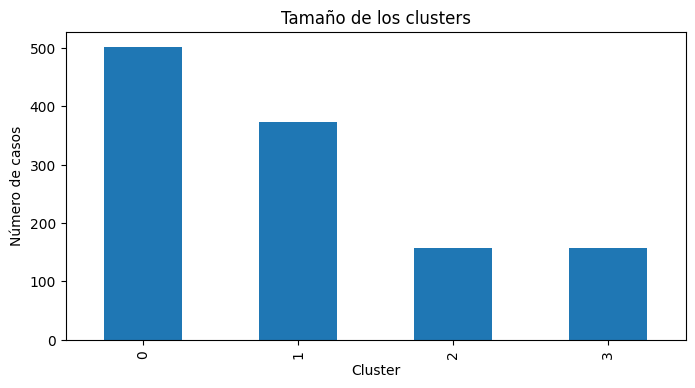

In [122]:
# =========================================
# BLOQUE 49: TAMAÑO DE CLUSTERS
# =========================================

df_model["CLUSTER"].value_counts().sort_index().plot(kind="bar", figsize=(8, 4))
plt.title("Tamaño de los clusters")
plt.xlabel("Cluster")
plt.ylabel("Número de casos")
plt.show()

In [ ]:
#BLOQUE 50. Gráfica 2: porcentaje de consumada y evitada por cluster

DELITO2A_PARTE,CONSUMADA,EVITADA
CLUSTER,,
0,10.96,89.04
1,11.29,88.71
2,17.20,82.80
3,15.19,84.81


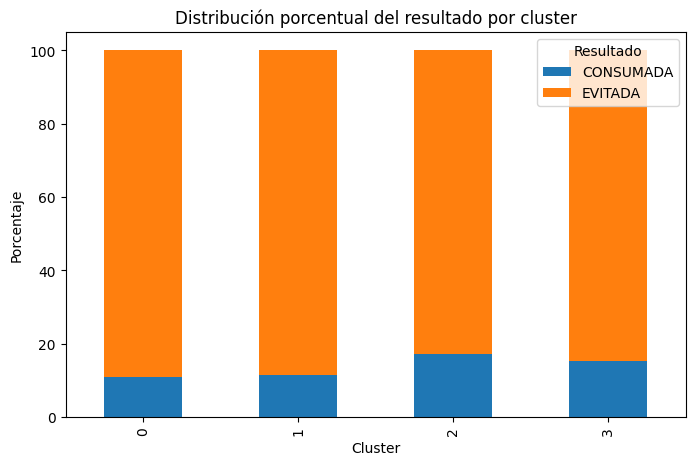

In [123]:
# =========================================
# BLOQUE 50: RESULTADO POR CLUSTER
# =========================================

tabla_cluster_resultado_plot = pd.crosstab(
    df_model["CLUSTER"],
    df_model["DELITO2A_PARTE"],
    normalize="index"
) * 100

tabla_cluster_resultado_plot = tabla_cluster_resultado_plot.round(2)

display(tabla_cluster_resultado_plot)

tabla_cluster_resultado_plot.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Distribución porcentual del resultado por cluster")
plt.xlabel("Cluster")
plt.ylabel("Porcentaje")
plt.legend(title="Resultado")
plt.show()

In [ ]:
#BLOQUE 51. Gráfica 3: visualización de clusters con t-SNE
#Esto sí te da una “gráfica de clusters” visual

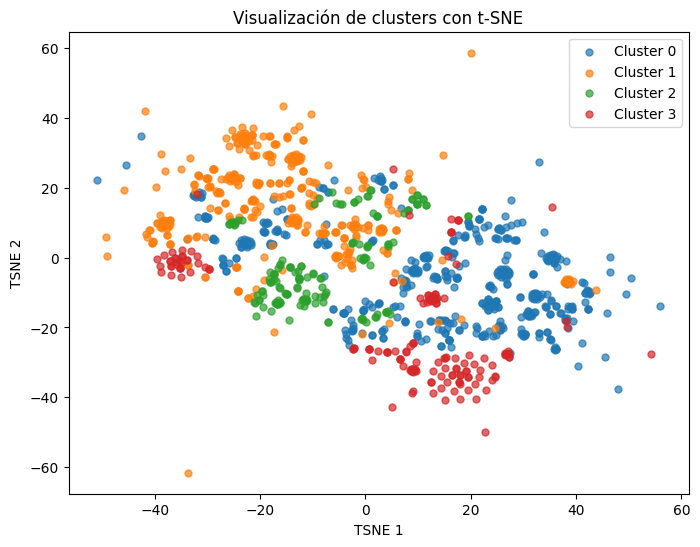

In [124]:
# =========================================
# BLOQUE 51: VISUALIZACIÓN t-SNE DE CLUSTERS
# =========================================

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="random"
)

X_tsne = tsne.fit_transform(X_cluster_dummy)

df_model["TSNE_1"] = X_tsne[:, 0]
df_model["TSNE_2"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))

for c in sorted(df_model["CLUSTER"].unique()):
    sub = df_model[df_model["CLUSTER"] == c]
    plt.scatter(
        sub["TSNE_1"],
        sub["TSNE_2"],
        label=f"Cluster {c}",
        alpha=0.7,
        s=25
    )

plt.title("Visualización de clusters con t-SNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.show()

In [ ]:
#BLOQUE 52. Gráfica 4: cluster vs porcentaje de consumada

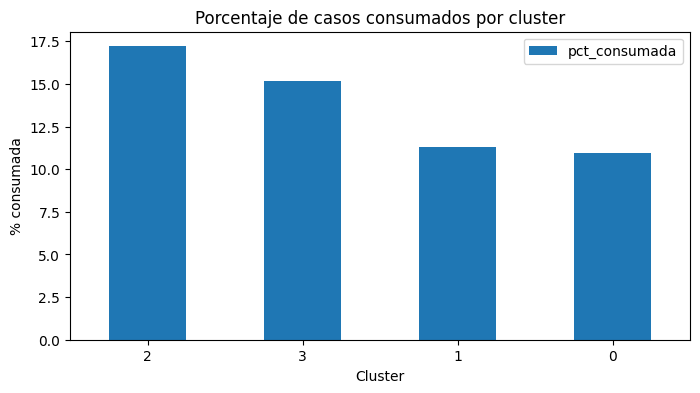

In [125]:
# =========================================
# BLOQUE 52: % CONSUMADA POR CLUSTER
# =========================================

metricas_por_cluster.sort_values("pct_consumada", ascending=False).plot(
    x="cluster",
    y="pct_consumada",
    kind="bar",
    figsize=(8, 4)
)

plt.title("Porcentaje de casos consumados por cluster")
plt.xlabel("Cluster")
plt.ylabel("% consumada")
plt.xticks(rotation=0)
plt.show()